### Experimental Setup

In [1]:
FEATURE_SELECTION_METHOD = "FLAML"
DEEP_LEARNING_CATEGORY = "Attention"
MODEL_ARCHITECTURE = "DistilGPT2"
DATASET_NAME = "Pattern"

**Developed By:** eDySec Research Team   
**Plartform:** Ubuntu 

All experiments in this notebook were conducted using **Python 3.10** with the following libraries:

`pandas==1.5.3`,  
`scikit-learn==1.2.2`,  
`openpyxl`,  
`numpy==1.23.5`,  
`scipy==1.9.3`,  
`tensorflow==2.11.0`,  
`matplotlib==3.7.1`,  
`seaborn==0.12.2`,  
`joblib==1.3.2`,  
`shap==0.41.0`,  
`lime`,  
`flaml[automl]==2.5.0`,  
`notebook==6.5.6`,  
`pywinpty==2.0.10`  (Only for windows)  `threadpoolctl==3.1.0` (for Ubuntu)   
`terminado==0.17.1`,  
`transformers==4.49.0`.

#### Full Environment Setup: https://github.com/tanzirmehedi/eDySec

These versions were used to ensure **consistent and reproducible experimental results**.

### Python Version Checking

In [2]:
# ============================================================
# Python Environment Verification
# ============================================================

# Display the current Python version to ensure compatibility
# with the required libraries and experimental setup

!python --version

/bin/bash: /home/n11894571/miniconda3/envs/tf211gpu/lib/libtinfo.so.6: no version information available (required by /bin/bash)
Python 3.10.20


### GPU Checking

In [3]:
# ============================================================
# GPU Status and Resource Monitoring
# ============================================================

# Display NVIDIA GPU information including driver version,
# CUDA version, memory usage, and active processes

!nvidia-smi

/bin/bash: /home/n11894571/miniconda3/envs/tf211gpu/lib/libtinfo.so.6: no version information available (required by /bin/bash)
Thu Mar 26 08:15:31 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 595.54                 Driver Version: 595.79         CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX A6000               On  |   00000000:01:00.0  On |                  Off |
| 30%   32C    P8             12W /  300W |   47262MiB /  49140MiB |      4%      Default |
|           

### Install Necessary Packages

In [3]:
# ============================================================
# Dependency Installation
# ============================================================

# Install all required packages from requirements.txt
# --no-cache-dir ensures a clean installation without using cached packages

!pip install --no-cache-dir -r requirements.txt

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
INFO: pip is looking at multiple versions of scikit-image to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of ipykernel to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 59.3 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.6/9.6 MB 90.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 87.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.7/33.7 MB 50.7 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 58.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.8/529.8 kB 67.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 532.9/532.9 kB 79.8 MB/s  0:00:00
   ━━━━━━━━━

### Import Necessary Packages

In [4]:
# ============================================================
# Standard Library
# ============================================================
import os
import gc
import time
import warnings

warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

# ============================================================
# Numerical and Data Processing
# ============================================================
import numpy as np
import pandas as pd

# ============================================================
# Visualization
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# Scikit-learn
# ============================================================
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    auc,
    precision_score,
    recall_score,
    f1_score,
    precision_recall_fscore_support,
    cohen_kappa_score,
)
from scipy.sparse import hstack, csr_matrix

# ============================================================
# TensorFlow / Keras
# ============================================================
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    LSTM,
    Dense,
    Dropout,
    BatchNormalization,
)
from tensorflow.keras.callbacks import (
    ModelCheckpoint,
    EarlyStopping,
    ReduceLROnPlateau,
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# ============================================================
# Transformers
# ============================================================
from transformers import (
    BertTokenizer,
    TFBertModel,
    GPT2Tokenizer,
    TFGPT2Model,
)

# ============================================================
# AutoML and Model Persistence
# ============================================================
from flaml import AutoML
import joblib

### GPU Status Checking

In [5]:
# ============================================================
# Detailed System and GPU Diagnostics
# ============================================================

print("=" * 60)
print("TensorFlow Environment Diagnostics")
print("=" * 60)

print(f"Conda Prefix        : {os.environ.get('CONDA_PREFIX')}")
print(f"LD_LIBRARY_PATH     : {os.environ.get('LD_LIBRARY_PATH')}")
print(f"TensorFlow Version  : {tf.__version__}")
print(f"Built with CUDA     : {tf.test.is_built_with_cuda()}")

gpus = tf.config.list_physical_devices('GPU')
print(f"Number of GPUs      : {len(gpus)}")

for idx, gpu in enumerate(gpus):
    print(f"GPU {idx}            : {gpu}")

print("=" * 60)

TensorFlow Environment Diagnostics
Conda Prefix        : /home/n11894571/miniconda3/envs/tf211gpu
LD_LIBRARY_PATH     : /home/n11894571/miniconda3/envs/tf211gpu/lib:
TensorFlow Version  : 2.11.0
Built with CUDA     : True
Number of GPUs      : 1
GPU 0            : PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


### Allocate as Much GPU Memory as Needed

In [6]:
# ============================================================
# Advanced GPU Configuration and Diagnostics
# ============================================================

gpus = tf.config.list_physical_devices('GPU')

print("=" * 60)
print("GPU Configuration")
print("=" * 60)

if gpus:
    print(f"Number of GPUs detected: {len(gpus)}")
    
    try:
        for idx, gpu in enumerate(gpus):
            # Disable memory growth (allocate full GPU memory)
            tf.config.experimental.set_memory_growth(gpu, False)
            print(f"GPU {idx}: Memory growth disabled (full allocation mode)")
    
    except RuntimeError as e:
        print(f"RuntimeError: {e}")
else:
    print("No GPU detected. Using CPU.")

print("=" * 60)

GPU Configuration
Number of GPUs detected: 1
GPU 0: Memory growth disabled (full allocation mode)


### Load QUT-DV25 Dataset

In [7]:
# ============================================================
# Data Loading and Initial Inspection
# ============================================================

# Define the dataset file path
file_path = 'QUT-DV25_'+DATASET_NAME+'_Traces.csv'

# Load the dataset into a pandas DataFrame
data = pd.read_csv(file_path)

# Display the first few rows for initial inspection
data.head()

,Package_Name,Pattern_1,Pattern_2,Pattern_3,Pattern_4,Pattern_5,Pattern_6,Pattern_7,Pattern_8,Pattern_9,Pattern_10,Level
0,10Cent10-999.0.4.tar.gz,newfstatat -> newfstatat -> newfstatat,fstat -> ioctl -> lseek,openat -> fstat -> ioctl,newfstatat -> newfstatat -> openat,newfstatat -> openat -> fstat,newfstatat -> newfstatat -> newfstatat -> no-e...,fstat -> ioctl -> lseek -> no-error -> no-fd,openat -> fstat -> ioctl -> no-error -> no-fd,ioctl -> lseek -> lseek -> error=ENOTTY -> no-fd,read -> read -> close -> no-error -> no-fd,1
1,10Cent11-999.0.4.tar.gz,newfstatat -> newfstatat -> newfstatat,read -> read -> read,newfstatat -> openat -> fstat,ioctl -> ioctl -> ioctl,newfstatat -> newfstatat -> openat,newfstatat -> newfstatat -> newfstatat -> no-e...,read -> read -> read -> no-error -> no-fd,newfstatat -> openat -> fstat -> no-error -> n...,ioctl -> ioctl -> ioctl -> no-error -> no-fd,fcntl -> fstat -> fcntl -> no-error -> no-fd,1
2,11Cent-999.0.0.tar.gz,newfstatat -> newfstatat -> newfstatat,newfstatat -> newfstatat -> openat,read -> read -> read,newfstatat -> openat -> fstat,fstat -> ioctl -> lseek,newfstatat -> newfstatat -> newfstatat -> no-e...,newfstatat -> newfstatat -> openat -> no-error...,read -> read -> read -> no-error -> no-fd,openat -> fstat -> ioctl -> no-error -> no-fd,newfstatat -> openat -> fstat -> no-error -> n...,1
3,11Cent-999.0.1.tar.gz,newfstatat -> newfstatat -> newfstatat,read -> read -> read,newfstatat -> openat -> fstat,openat -> fstat -> fcntl,fstat -> fcntl -> fstat,newfstatat -> newfstatat -> newfstatat -> no-e...,read -> read -> read -> no-error -> no-fd,newfstatat -> openat -> fstat -> no-error -> n...,openat -> fstat -> fcntl -> no-error -> no-fd,fstat -> fcntl -> fstat -> no-error -> no-fd,1
4,11Cent-999.0.2.tar.gz,newfstatat -> newfstatat -> newfstatat,read -> read -> read,newfstatat -> openat -> fstat,read -> poll -> read,poll -> read -> read,newfstatat -> newfstatat -> newfstatat -> no-e...,read -> read -> read -> no-error -> no-fd,newfstatat -> openat -> fstat -> no-error -> n...,read -> poll -> read -> error=EAGAIN -> no-fd,newfstatat -> newfstatat -> openat -> no-error...,1


### Clear Backend Session

In [8]:
# ============================================================
# Memory Management and Session Reset
# ============================================================

# Trigger garbage collection to free unused memory
gc.collect()

# Clear the current TensorFlow/Keras session to release GPU/CPU resources
# This is particularly important when training multiple models sequentially
tf.keras.backend.clear_session()

### Feature Processing

In [9]:
# Remove non-informative identifier column if present
if 'Package_Name' in data.columns:
    data = data.drop(columns=['Package_Name'])

# Identify categorical feature columns, excluding the target label
categorical_columns = [
    col for col in data.columns
    if data[col].dtype == 'object' and col != 'Level'
]

# Use temporary variable instead of adding new dataframe column
combined_categorical = (
    data[categorical_columns]
    .fillna('')
    .astype(str)
    .agg(' '.join, axis=1)
)

# Vectorize categorical text
vectorizer = CountVectorizer(ngram_range=(2, 3))
categorical_ngram_features = vectorizer.fit_transform(combined_categorical)

# Select only numerical columns
numerical_columns = [
    col for col in data.columns
    if col != 'Level' and pd.api.types.is_numeric_dtype(data[col])
]

# Prepare numerical features
numerical_features = data[numerical_columns].fillna(0).astype(float)
numerical_features_sparse = csr_matrix(numerical_features.values)

# Combine
X = hstack([numerical_features_sparse, categorical_ngram_features])

# Scale
scaler = StandardScaler(with_mean=False)
X_scaled = scaler.fit_transform(X)

### AutoML Implementation

In [10]:
# Assume 'data' is your pandas DataFrame
X = data.drop(columns=['Level'])
y = data['Level']

if y.dtype == 'object' or y.dtype.name == 'category':
    y = LabelEncoder().fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Initialize FLAML
automl = AutoML()
automl_settings = {
    "time_budget": 60,
    "metric": "accuracy",
    "task": "classification",
}

automl.fit(X_train=X_train, y_train=y_train, **automl_settings)

# Feature importance & selection
selected_features = X.columns.tolist()
dropped_features = []

try:
    importances = automl.model.feature_importances_

    # Sometimes LGBM may drop unused features -> align with all columns
    if len(importances) < X.shape[1]:
        full_importances = np.zeros(X.shape[1])
        # Use feature names from model if available
        try:
            model_features = automl.model.booster_.feature_name()
            for i, col in enumerate(X.columns):
                if col in model_features:
                    idx = model_features.index(col)
                    full_importances[i] = importances[idx]
        except:
            full_importances[:len(importances)] = importances
        importances = full_importances

    varimp = pd.DataFrame({'variable': X.columns, 'importance': importances})
    varimp['relative_importance'] = varimp['importance'] / varimp['importance'].sum()

    threshold = 0.03
    selected_features = list(varimp[varimp['relative_importance'] > threshold]['variable'])
    dropped_features = list(varimp[varimp['relative_importance'] <= threshold]['variable'])

    print("Feature importance table:\n", varimp)

except AttributeError:
    print("Feature importance not available for the chosen model.")

print("\nSelected features:", selected_features)
print("Number of features kept:", len(selected_features))
print("\nDropped features:", dropped_features)
print("Number of features dropped:", len(dropped_features))

[flaml.automl.logger: 03-26 08:16:04] {2375} INFO - task = classification
[flaml.automl.logger: 03-26 08:16:04] {2386} INFO - Evaluation method: cv
[flaml.automl.logger: 03-26 08:16:04] {2489} INFO - Minimizing error metric: 1-accuracy
[flaml.automl.logger: 03-26 08:16:04] {2606} INFO - List of ML learners in AutoML Run: ['lgbm', 'rf', 'xgboost', 'extra_tree', 'xgb_limitdepth', 'sgd', 'lrl1']
[flaml.automl.logger: 03-26 08:16:04] {2911} INFO - iteration 0, current learner lgbm
[flaml.automl.logger: 03-26 08:16:04] {3046} INFO - Estimated sufficient time budget=679s. Estimated necessary time budget=16s.
[flaml.automl.logger: 03-26 08:16:04] {3097} INFO -  at 0.1s,	estimator lgbm's best error=2.1654e-01,	best estimator lgbm's best error=2.1654e-01
[flaml.automl.logger: 03-26 08:16:04] {2911} INFO - iteration 1, current learner lgbm
[flaml.automl.logger: 03-26 08:16:05] {3097} INFO -  at 0.2s,	estimator lgbm's best error=2.1534e-01,	best estimator lgbm's best error=2.1534e-01
[flaml.autom

[flaml.automl.logger: 03-26 08:16:09] {2911} INFO - iteration 33, current learner lgbm
[flaml.automl.logger: 03-26 08:16:09] {3097} INFO -  at 5.0s,	estimator lgbm's best error=1.2574e-01,	best estimator lgbm's best error=1.2574e-01
[flaml.automl.logger: 03-26 08:16:09] {2911} INFO - iteration 34, current learner extra_tree
[flaml.automl.logger: 03-26 08:16:10] {3097} INFO -  at 5.2s,	estimator extra_tree's best error=2.7941e-01,	best estimator lgbm's best error=1.2574e-01
[flaml.automl.logger: 03-26 08:16:10] {2911} INFO - iteration 35, current learner lgbm
[flaml.automl.logger: 03-26 08:16:10] {3097} INFO -  at 5.4s,	estimator lgbm's best error=1.2574e-01,	best estimator lgbm's best error=1.2574e-01
[flaml.automl.logger: 03-26 08:16:10] {2911} INFO - iteration 36, current learner lgbm
[flaml.automl.logger: 03-26 08:16:10] {3097} INFO -  at 5.5s,	estimator lgbm's best error=1.2574e-01,	best estimator lgbm's best error=1.2574e-01
[flaml.automl.logger: 03-26 08:16:10] {2911} INFO - iter

[flaml.automl.logger: 03-26 08:16:19] {2911} INFO - iteration 68, current learner xgboost
[flaml.automl.logger: 03-26 08:16:20] {3097} INFO -  at 16.1s,	estimator xgboost's best error=1.2474e-01,	best estimator lgbm's best error=1.2454e-01
[flaml.automl.logger: 03-26 08:16:20] {2911} INFO - iteration 69, current learner lgbm
[flaml.automl.logger: 03-26 08:16:21] {3097} INFO -  at 16.2s,	estimator lgbm's best error=1.2454e-01,	best estimator lgbm's best error=1.2454e-01
[flaml.automl.logger: 03-26 08:16:21] {2911} INFO - iteration 70, current learner xgboost
[flaml.automl.logger: 03-26 08:16:22] {3097} INFO -  at 17.2s,	estimator xgboost's best error=1.2474e-01,	best estimator lgbm's best error=1.2454e-01
[flaml.automl.logger: 03-26 08:16:22] {2911} INFO - iteration 71, current learner xgboost
[flaml.automl.logger: 03-26 08:16:23] {3097} INFO -  at 18.5s,	estimator xgboost's best error=1.2474e-01,	best estimator lgbm's best error=1.2454e-01
[flaml.automl.logger: 03-26 08:16:23] {2911} I

[flaml.automl.logger: 03-26 08:16:41] {2911} INFO - iteration 103, current learner lgbm
[flaml.automl.logger: 03-26 08:16:42] {3097} INFO -  at 37.2s,	estimator lgbm's best error=1.2283e-01,	best estimator lgbm's best error=1.2283e-01
[flaml.automl.logger: 03-26 08:16:42] {2911} INFO - iteration 104, current learner rf
[flaml.automl.logger: 03-26 08:16:42] {3097} INFO -  at 37.5s,	estimator rf's best error=1.3255e-01,	best estimator lgbm's best error=1.2283e-01
[flaml.automl.logger: 03-26 08:16:42] {2911} INFO - iteration 105, current learner lgbm
[flaml.automl.logger: 03-26 08:16:51] {3097} INFO -  at 46.5s,	estimator lgbm's best error=1.2283e-01,	best estimator lgbm's best error=1.2283e-01
[flaml.automl.logger: 03-26 08:16:51] {2911} INFO - iteration 106, current learner xgb_limitdepth
[flaml.automl.logger: 03-26 08:16:51] {3097} INFO -  at 46.6s,	estimator xgb_limitdepth's best error=1.4386e-01,	best estimator lgbm's best error=1.2283e-01
[flaml.automl.logger: 03-26 08:16:51] {2911}

### Selected Features

In [11]:
selected_features = ['Pattern_2', 'Pattern_3', 'Pattern_4', 'Pattern_5', 'Pattern_7', 'Pattern_8', 'Pattern_9', 'Pattern_10']

### Data Preprocessing

In [12]:
# ============================================================
# Feature Selection and Dataset Preparation
# ============================================================

# Select the predefined feature subset
selected_features_with_target = selected_features.copy()

# Create a feature matrix from the selected features
X = data[selected_features_with_target].copy()

# Define the target variable
y = data['Level']

# ============================================================
# Train–Validation–Test Split (70%–15%–15%)
# ============================================================

# Step 1: Split into training (70%) and temporary set (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Step 2: Split temporary set into validation (15%) and test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

# ============================================================
# Dataset Summary
# ============================================================

print(f"Training set shape     : {X_train.shape}")
print(f"Validation set shape   : {X_val.shape}")
print(f"Test set shape         : {X_test.shape}")

Training set shape     : (9989, 8)
Validation set shape   : (2141, 8)
Test set shape         : (2141, 8)


### Setup OUTPUT_DIR

In [13]:
OUTPUT_DIR = "Evaluation_Outputs_"+DATASET_NAME+"_"+FEATURE_SELECTION_METHOD+"_"+DEEP_LEARNING_CATEGORY+"_"+MODEL_ARCHITECTURE
os.makedirs(OUTPUT_DIR, exist_ok=True)
OUTPUT_DIR

'Evaluation_Outputs_Pattern_FLAML_Attention_DistilGPT2'

### Model

In [14]:
# ============================================================
# Define model saving configuration
# ============================================================

SAVE_DIR = OUTPUT_DIR
MODEL_NAME = os.path.join(SAVE_DIR, OUTPUT_DIR + ".h5")


# =========================================================
# Detect categorical and numeric columns
# =========================================================

categorical_cols = X_train.select_dtypes(include=['object']).columns
numeric_cols = X_train.select_dtypes(include=[np.number]).columns


# =========================================================
# Convert each row into a single text string
# =========================================================

def row_to_text(row):

    text = " ".join([f"{col}:{row[col]}" for col in categorical_cols])
    
    return text

X_train_text = X_train.apply(row_to_text, axis=1)
X_val_text   = X_val.apply(row_to_text, axis=1)
X_test_text  = X_test.apply(row_to_text, axis=1)


# =========================================================
# Load DistilGPT2 tokenizer and model
# =========================================================

MODEL = "distilgpt2"
tokenizer = GPT2Tokenizer.from_pretrained(MODEL)
tokenizer.pad_token = tokenizer.eos_token
gpt_model = TFGPT2Model.from_pretrained(MODEL)


# =========================================================
# Tokenization
# =========================================================

MAX_LEN = 64

def encode_texts(texts):

    enc = tokenizer(
        list(texts),
        padding="max_length",
        truncation=True,
        max_length=MAX_LEN,
        return_tensors="tf"
    )

    return enc

train_enc = encode_texts(X_train_text)
val_enc   = encode_texts(X_val_text)
test_enc  = encode_texts(X_test_text)


# =========================================================
# Process numeric features
# =========================================================

if len(numeric_cols) > 0:

    scaler = StandardScaler()

    X_train_num = scaler.fit_transform(X_train[numeric_cols])
    X_val_num   = scaler.transform(X_val[numeric_cols])
    X_test_num  = scaler.transform(X_test[numeric_cols])

else:

    X_train_num = np.empty((len(X_train), 0))
    X_val_num   = np.empty((len(X_val), 0))
    X_test_num  = np.empty((len(X_test), 0))

# Convert to float32
X_train_num = X_train_num.astype(np.float32)
X_val_num   = X_val_num.astype(np.float32)
X_test_num  = X_test_num.astype(np.float32)


# =========================================================
# Labels
# =========================================================

y_train = y_train.astype(np.float32)
y_val   = y_val.astype(np.float32)
y_test  = y_test.astype(np.float32)


# =========================================================
# Callbacks
# =========================================================

checkpoint_cb = ModelCheckpoint(
    MODEL_NAME,
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

reduce_lr_cb = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=200,
    verbose=1
)

early_stop_cb = EarlyStopping(
    monitor="val_loss",
    patience=200,
    restore_best_weights=True
)


# =========================================================
# Build DistilGPT2 Hybrid Model
# =========================================================

input_ids = tf.keras.Input(shape=(MAX_LEN,), dtype=tf.int32)
attention_mask = tf.keras.Input(shape=(MAX_LEN,), dtype=tf.int32)

# Transformer output
gpt_outputs = gpt_model(
    input_ids,
    attention_mask=attention_mask
)

# Use last token representation
text_features = gpt_outputs.last_hidden_state[:, -1, :]

# Numeric input
num_input = tf.keras.Input(shape=(X_train_num.shape[1],))
num_branch = layers.Dense(64, activation="relu")(num_input)
num_branch = layers.Dropout(0.2)(num_branch)

# Combine text + numeric
x = layers.Concatenate()([text_features, num_branch])

# Classification head
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dense(64, activation="relu")(x)

output = layers.Dense(1, activation="sigmoid")(x)

model = models.Model(
    inputs=[input_ids, attention_mask, num_input],
    outputs=output
)

model.compile(
    optimizer=tf.keras.optimizers.legacy.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

All PyTorch model weights were used when initializing TFGPT2Model.

All the weights of TFGPT2Model were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFGPT2Model for predictions without further training.


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 64)]         0           []                               
                                                                                                  
 input_2 (InputLayer)           [(None, 64)]         0           []                               
                                                                                                  
 input_3 (InputLayer)           [(None, 0)]          0           []                               
                                                                                                  
 tfgpt2_model (TFGPT2Model)     TFBaseModelOutputWi  81912576    ['input_1[0][0]',                
                                thPastAndCrossAtten               'input_2[0][0]']            

### Compime the Model

In [15]:
# ==========================
# Train model
# ==========================

start_train = time.time()

history = model.fit(

    [
        train_enc["input_ids"],
        train_enc["attention_mask"],
        X_train_num
    ],

    y_train,

    validation_data=(

        [
            val_enc["input_ids"],
            val_enc["attention_mask"],
            X_val_num
        ],

        y_val
    ),

    epochs=200,
    batch_size=16,

    callbacks=[
        checkpoint_cb,
        reduce_lr_cb,
        early_stop_cb
    ]

)

end_train = time.time()
training_time = end_train - start_train

Epoch 1/200
624/625 [============================>.] - ETA: 0s - loss: 0.5538 - accuracy: 0.7111
Epoch 1: val_accuracy improved from -inf to 0.78468, saving model to Evaluation_Outputs_Pattern_FLAML_Attention_DistilGPT2/Evaluation_Outputs_Pattern_FLAML_Attention_DistilGPT2.h5
625/625 [==============================] - 33s 45ms/step - loss: 0.5538 - accuracy: 0.7111 - val_loss: 0.4365 - val_accuracy: 0.7847 - lr: 1.0000e-04
Epoch 2/200
625/625 [==============================] - ETA: 0s - loss: 0.4404 - accuracy: 0.7983
Epoch 2: val_accuracy improved from 0.78468 to 0.81317, saving model to Evaluation_Outputs_Pattern_FLAML_Attention_DistilGPT2/Evaluation_Outputs_Pattern_FLAML_Attention_DistilGPT2.h5
625/625 [==============================] - 26s 42ms/step - loss: 0.4404 - accuracy: 0.7983 - val_loss: 0.4086 - val_accuracy: 0.8132 - lr: 1.0000e-04
Epoch 3/200
625/625 [==============================] - ETA: 0s - loss: 0.4106 - accuracy: 0.8141
Epoch 3: val_accuracy improved from 0.81317 to

625/625 [==============================] - ETA: 0s - loss: 0.3305 - accuracy: 0.8538
Epoch 23: val_accuracy improved from 0.85754 to 0.85801, saving model to Evaluation_Outputs_Pattern_FLAML_Attention_DistilGPT2/Evaluation_Outputs_Pattern_FLAML_Attention_DistilGPT2.h5
625/625 [==============================] - 26s 42ms/step - loss: 0.3305 - accuracy: 0.8538 - val_loss: 0.3388 - val_accuracy: 0.8580 - lr: 1.0000e-04
Epoch 24/200
625/625 [==============================] - ETA: 0s - loss: 0.3277 - accuracy: 0.8560
Epoch 24: val_accuracy improved from 0.85801 to 0.85894, saving model to Evaluation_Outputs_Pattern_FLAML_Attention_DistilGPT2/Evaluation_Outputs_Pattern_FLAML_Attention_DistilGPT2.h5
625/625 [==============================] - 26s 42ms/step - loss: 0.3277 - accuracy: 0.8560 - val_loss: 0.3518 - val_accuracy: 0.8589 - lr: 1.0000e-04
Epoch 25/200
625/625 [==============================] - ETA: 0s - loss: 0.3277 - accuracy: 0.8549
Epoch 25: val_accuracy did not improve from 0.85894

624/625 [============================>.] - ETA: 0s - loss: 0.3127 - accuracy: 0.8596
Epoch 49: val_accuracy did not improve from 0.86128
625/625 [==============================] - 29s 47ms/step - loss: 0.3128 - accuracy: 0.8594 - val_loss: 0.3464 - val_accuracy: 0.8603 - lr: 1.0000e-04
Epoch 50/200
625/625 [==============================] - ETA: 0s - loss: 0.3131 - accuracy: 0.8618
Epoch 50: val_accuracy did not improve from 0.86128
625/625 [==============================] - 26s 42ms/step - loss: 0.3131 - accuracy: 0.8618 - val_loss: 0.3500 - val_accuracy: 0.8589 - lr: 1.0000e-04
Epoch 51/200
624/625 [============================>.] - ETA: 0s - loss: 0.3134 - accuracy: 0.8599
Epoch 51: val_accuracy did not improve from 0.86128
625/625 [==============================] - 26s 41ms/step - loss: 0.3136 - accuracy: 0.8597 - val_loss: 0.3516 - val_accuracy: 0.8608 - lr: 1.0000e-04
Epoch 52/200
625/625 [==============================] - ETA: 0s - loss: 0.3122 - accuracy: 0.8589
Epoch 52: val_a

625/625 [==============================] - 26s 41ms/step - loss: 0.3081 - accuracy: 0.8607 - val_loss: 0.3725 - val_accuracy: 0.8585 - lr: 1.0000e-04
Epoch 77/200
625/625 [==============================] - ETA: 0s - loss: 0.3068 - accuracy: 0.8623
Epoch 77: val_accuracy did not improve from 0.86128
625/625 [==============================] - 26s 41ms/step - loss: 0.3068 - accuracy: 0.8623 - val_loss: 0.3665 - val_accuracy: 0.8571 - lr: 1.0000e-04
Epoch 78/200
625/625 [==============================] - ETA: 0s - loss: 0.3054 - accuracy: 0.8641
Epoch 78: val_accuracy did not improve from 0.86128
625/625 [==============================] - 26s 41ms/step - loss: 0.3054 - accuracy: 0.8641 - val_loss: 0.3599 - val_accuracy: 0.8603 - lr: 1.0000e-04
Epoch 79/200
625/625 [==============================] - ETA: 0s - loss: 0.3046 - accuracy: 0.8647
Epoch 79: val_accuracy did not improve from 0.86128
625/625 [==============================] - 26s 41ms/step - loss: 0.3046 - accuracy: 0.8647 - val_los

625/625 [==============================] - 25s 40ms/step - loss: 0.3061 - accuracy: 0.8616 - val_loss: 0.3754 - val_accuracy: 0.8589 - lr: 1.0000e-04
Epoch 104/200
625/625 [==============================] - ETA: 0s - loss: 0.3032 - accuracy: 0.8638
Epoch 104: val_accuracy did not improve from 0.86221
625/625 [==============================] - 25s 40ms/step - loss: 0.3032 - accuracy: 0.8638 - val_loss: 0.3941 - val_accuracy: 0.8603 - lr: 1.0000e-04
Epoch 105/200
625/625 [==============================] - ETA: 0s - loss: 0.3045 - accuracy: 0.8635
Epoch 105: val_accuracy did not improve from 0.86221
625/625 [==============================] - 25s 40ms/step - loss: 0.3045 - accuracy: 0.8635 - val_loss: 0.3975 - val_accuracy: 0.8622 - lr: 1.0000e-04
Epoch 106/200
625/625 [==============================] - ETA: 0s - loss: 0.3026 - accuracy: 0.8637
Epoch 106: val_accuracy did not improve from 0.86221
625/625 [==============================] - 25s 40ms/step - loss: 0.3026 - accuracy: 0.8637 - v

625/625 [==============================] - ETA: 0s - loss: 0.3029 - accuracy: 0.8653
Epoch 130: val_accuracy did not improve from 0.86315
625/625 [==============================] - 25s 40ms/step - loss: 0.3029 - accuracy: 0.8653 - val_loss: 0.3572 - val_accuracy: 0.8631 - lr: 1.0000e-04
Epoch 131/200
625/625 [==============================] - ETA: 0s - loss: 0.3063 - accuracy: 0.8635
Epoch 131: val_accuracy did not improve from 0.86315
625/625 [==============================] - 25s 40ms/step - loss: 0.3063 - accuracy: 0.8635 - val_loss: 0.3531 - val_accuracy: 0.8585 - lr: 1.0000e-04
Epoch 132/200
625/625 [==============================] - ETA: 0s - loss: 0.3039 - accuracy: 0.8642
Epoch 132: val_accuracy did not improve from 0.86315
625/625 [==============================] - 25s 40ms/step - loss: 0.3039 - accuracy: 0.8642 - val_loss: 0.3845 - val_accuracy: 0.8589 - lr: 1.0000e-04
Epoch 133/200
625/625 [==============================] - ETA: 0s - loss: 0.3030 - accuracy: 0.8640
Epoch 133

625/625 [==============================] - ETA: 0s - loss: 0.2987 - accuracy: 0.8652
Epoch 157: val_accuracy did not improve from 0.86315
625/625 [==============================] - 25s 40ms/step - loss: 0.2987 - accuracy: 0.8652 - val_loss: 0.4052 - val_accuracy: 0.8589 - lr: 1.0000e-04
Epoch 158/200
625/625 [==============================] - ETA: 0s - loss: 0.3004 - accuracy: 0.8641
Epoch 158: val_accuracy did not improve from 0.86315
625/625 [==============================] - 25s 40ms/step - loss: 0.3004 - accuracy: 0.8641 - val_loss: 0.4260 - val_accuracy: 0.8589 - lr: 1.0000e-04
Epoch 159/200
625/625 [==============================] - ETA: 0s - loss: 0.3008 - accuracy: 0.8645
Epoch 159: val_accuracy did not improve from 0.86315
625/625 [==============================] - 25s 40ms/step - loss: 0.3008 - accuracy: 0.8645 - val_loss: 0.3847 - val_accuracy: 0.8608 - lr: 1.0000e-04
Epoch 160/200
625/625 [==============================] - ETA: 0s - loss: 0.3016 - accuracy: 0.8647
Epoch 160

625/625 [==============================] - ETA: 0s - loss: 0.3004 - accuracy: 0.8648
Epoch 184: val_accuracy did not improve from 0.86315
625/625 [==============================] - 25s 40ms/step - loss: 0.3004 - accuracy: 0.8648 - val_loss: 0.3681 - val_accuracy: 0.8603 - lr: 1.0000e-04
Epoch 185/200
625/625 [==============================] - ETA: 0s - loss: 0.3022 - accuracy: 0.8648
Epoch 185: val_accuracy did not improve from 0.86315
625/625 [==============================] - 25s 40ms/step - loss: 0.3022 - accuracy: 0.8648 - val_loss: 0.3722 - val_accuracy: 0.8608 - lr: 1.0000e-04
Epoch 186/200
625/625 [==============================] - ETA: 0s - loss: 0.3009 - accuracy: 0.8658
Epoch 186: val_accuracy did not improve from 0.86315
625/625 [==============================] - 25s 40ms/step - loss: 0.3009 - accuracy: 0.8658 - val_loss: 0.3813 - val_accuracy: 0.8599 - lr: 1.0000e-04
Epoch 187/200
625/625 [==============================] - ETA: 0s - loss: 0.3001 - accuracy: 0.8657
Epoch 187

### Clear Backend Session

In [16]:
# ============================================================
# Memory Management and Session Reset
# ============================================================

# Trigger garbage collection to free unused memory
gc.collect()

# Clear the current TensorFlow/Keras session to release GPU/CPU resources
# This is particularly important when training multiple models sequentially
tf.keras.backend.clear_session()

### Model Validation

In [17]:
# ==========================
# Validation Evaluation
# ==========================

start_val = time.time()

val_loss, val_acc = model.evaluate(
    [
        val_enc["input_ids"],
        val_enc["attention_mask"],
        X_val_num
    ],
    y_val,
    verbose=0
)

end_val = time.time()
validation_time = end_val - start_val


# ==========================
# Test Evaluation
# ==========================

start_test = time.time()

test_loss, test_acc = model.evaluate(
    [
        test_enc["input_ids"],
        test_enc["attention_mask"],
        X_test_num
    ],
    y_test,
    verbose=0
)

end_test = time.time()
testing_time = end_test - start_test


# ==========================
# Print Results
# ==========================

print(f"\nTraining Time: {training_time:.2f} seconds")
print(f"Validation Time: {validation_time:.2f} seconds")
print(f"Testing Time: {testing_time:.2f} seconds")

print(f"\nValidation Accuracy: {val_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")


Training Time: 5080.48 seconds
Validation Time: 1.76 seconds
Testing Time: 1.24 seconds

Validation Accuracy: 0.8589
Test Accuracy: 0.8510


### Save Training Log

In [18]:
# Convert history to DataFrame
df = pd.DataFrame(history.history)

# Add epoch column (starting from 1)
df.insert(0, "epoch", range(1, len(df) + 1))

# Optional: round values for cleaner output
df = df.round(6)

# Define save path
training_log_path = os.path.join(
    OUTPUT_DIR,
    "training_log.xlsx"
)

# Save file
df.to_excel(training_log_path, index=False)

# Confirmation
print(f"Training log saved at: {training_log_path}")

# Preview
df.head()

Training log saved at: Evaluation_Outputs_Pattern_FLAML_Attention_DistilGPT2/training_log.xlsx


,epoch,loss,accuracy,val_loss,val_accuracy,lr
0,1,0.553790,0.711082,0.436511,0.784680,0.0001
1,2,0.440375,0.798278,0.408622,0.813171,0.0001
2,3,0.410581,0.814095,0.376530,0.829986,0.0001
3,4,0.396898,0.821704,0.383767,0.822513,0.0001
4,5,0.382635,0.829212,0.380003,0.828118,0.0001


### Trainig and Validation Plot

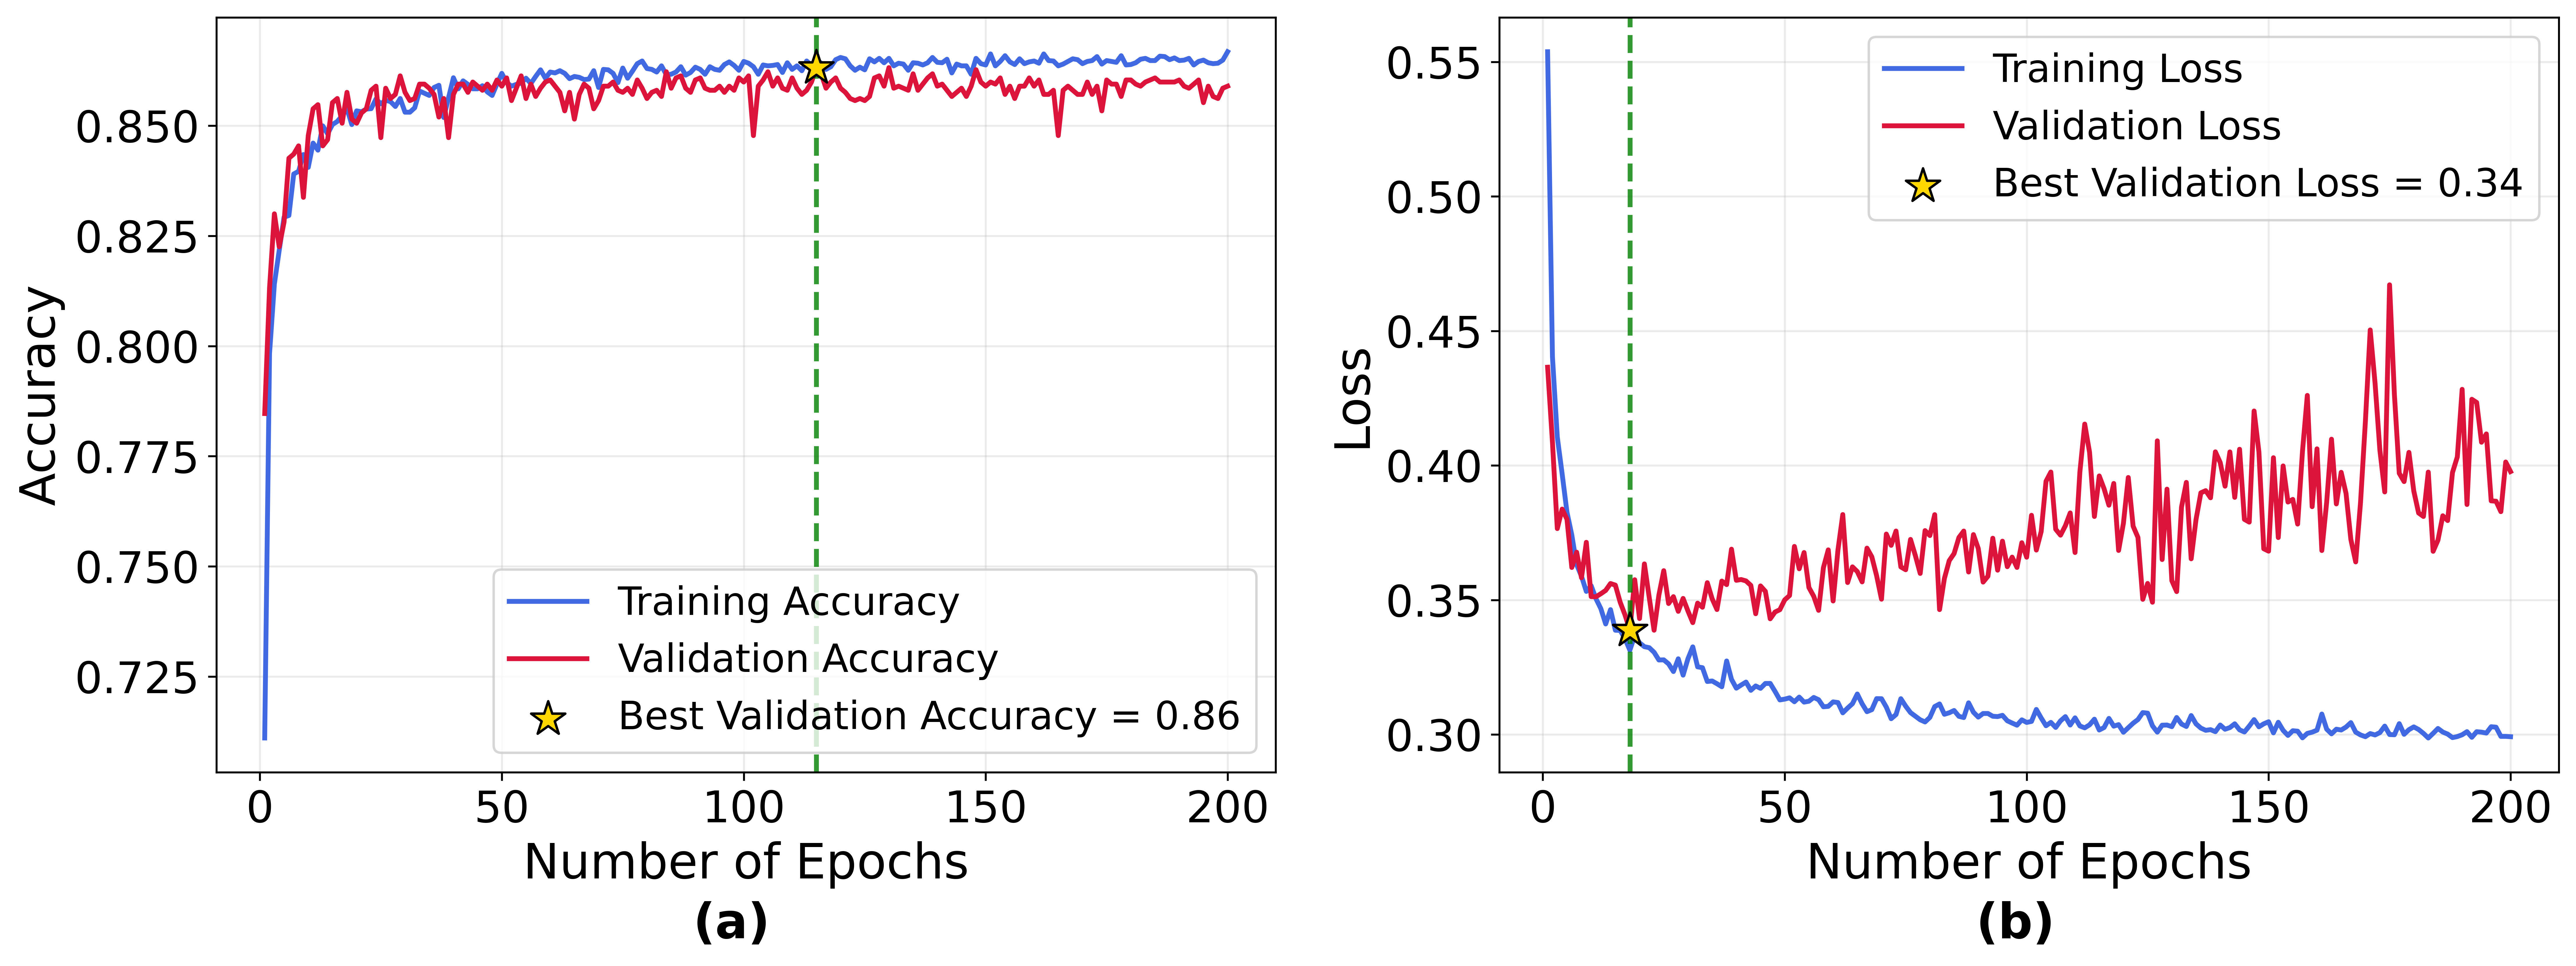

In [19]:
# ============================================================
# Font Settings
# ============================================================
plt.rcParams.update({
    "font.size": 20,
    "axes.titlesize": 20,
    "axes.labelsize": 20,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 16
})

# ============================================================
# Identify Best Epochs
# ============================================================

if "epoch" not in df.columns:
    df["epoch"] = range(1, len(df) + 1)

best_acc_idx = df["val_accuracy"].idxmax()
best_acc_epoch = int(df.loc[best_acc_idx, "epoch"])
best_acc = float(df.loc[best_acc_idx, "val_accuracy"])

best_loss_idx = df["val_loss"].idxmin()
best_loss_epoch = int(df.loc[best_loss_idx, "epoch"])
best_loss = float(df.loc[best_loss_idx, "val_loss"])

# ============================================================
# Combined Learning Curves
# ============================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), dpi=600)

# ============================================================
# Accuracy Plot
# ============================================================
ax1.plot(df["epoch"], df["accuracy"], linewidth=2,
         color="royalblue", label="Training Accuracy")

ax1.plot(df["epoch"], df["val_accuracy"], linewidth=2,
         color="crimson", label="Validation Accuracy")

ax1.axvline(best_acc_epoch,
            linestyle="--",
            linewidth=2,
            color="green",
            alpha=0.8)

ax1.scatter(best_acc_epoch, best_acc,
            s=220, marker="*", color="gold", edgecolor="black",
            zorder=3,
            label=f"Best Validation Accuracy = {best_acc:.2f}")

ax1.set_xlabel("Number of Epochs")
ax1.set_ylabel("Accuracy")
ax1.grid(True, alpha=0.25)
ax1.legend(frameon=True)

# Accuracy plot ticks
for tick, label in zip(ax1.get_xticks(), ax1.get_xticklabels()):
    if int(tick) == best_acc_epoch:
        label.set_fontweight("bold")
        label.set_color("green")
        
# ============================================================
# Loss Plot
# ============================================================
ax2.plot(df["epoch"], df["loss"], linewidth=2,
         color="royalblue", label="Training Loss")

ax2.plot(df["epoch"], df["val_loss"], linewidth=2,
         color="crimson", label="Validation Loss")

ax2.axvline(best_loss_epoch,
            linestyle="--",
            linewidth=2,
            color="green",
            alpha=0.8)

ax2.scatter(best_loss_epoch, best_loss,
            s=220, marker="*", color="gold", edgecolor="black",
            zorder=3,
            label=f"Best Validation Loss = {best_loss:.2f}")

ax2.set_xlabel("Number of Epochs")
ax2.set_ylabel("Loss")
ax2.grid(True, alpha=0.25)
ax2.legend(frameon=True)

# Loss plot ticks
for tick, label in zip(ax2.get_xticks(), ax2.get_xticklabels()):
    if int(tick) == best_loss_epoch:
        label.set_fontweight("bold")
        label.set_color("green")
        
# ============================================================
# Panel Labels
# ============================================================
ax1.text(0.45, -0.22, "(a)", transform=ax1.transAxes,
         fontsize=20, fontweight="bold")

ax2.text(0.45, -0.22, "(b)", transform=ax2.transAxes,
         fontsize=20, fontweight="bold")

# ============================================================
# Final layout
# ============================================================
fig.tight_layout()

fig.savefig(os.path.join(OUTPUT_DIR, "learning_curves.png"),
            dpi=600, bbox_inches="tight")

fig.savefig(os.path.join(OUTPUT_DIR, "learning_curves.pdf"),
            bbox_inches="tight")

plt.show()

### Classification Report


Evaluation Results: Train
Accuracy  : 0.866453
Precision : 0.879701
Recall    : 0.848667
F1-score  : 0.863905
ROC AUC   : 0.945090
----------------------------------------------------------------------
Classification Report:
              precision    recall  f1-score   support

         0.0   0.854134  0.884200  0.868907      5000
         1.0   0.879701  0.848667  0.863905      4989

    accuracy                       0.866453      9989
   macro avg   0.866918  0.866434  0.866406      9989
weighted avg   0.866904  0.866453  0.866409      9989



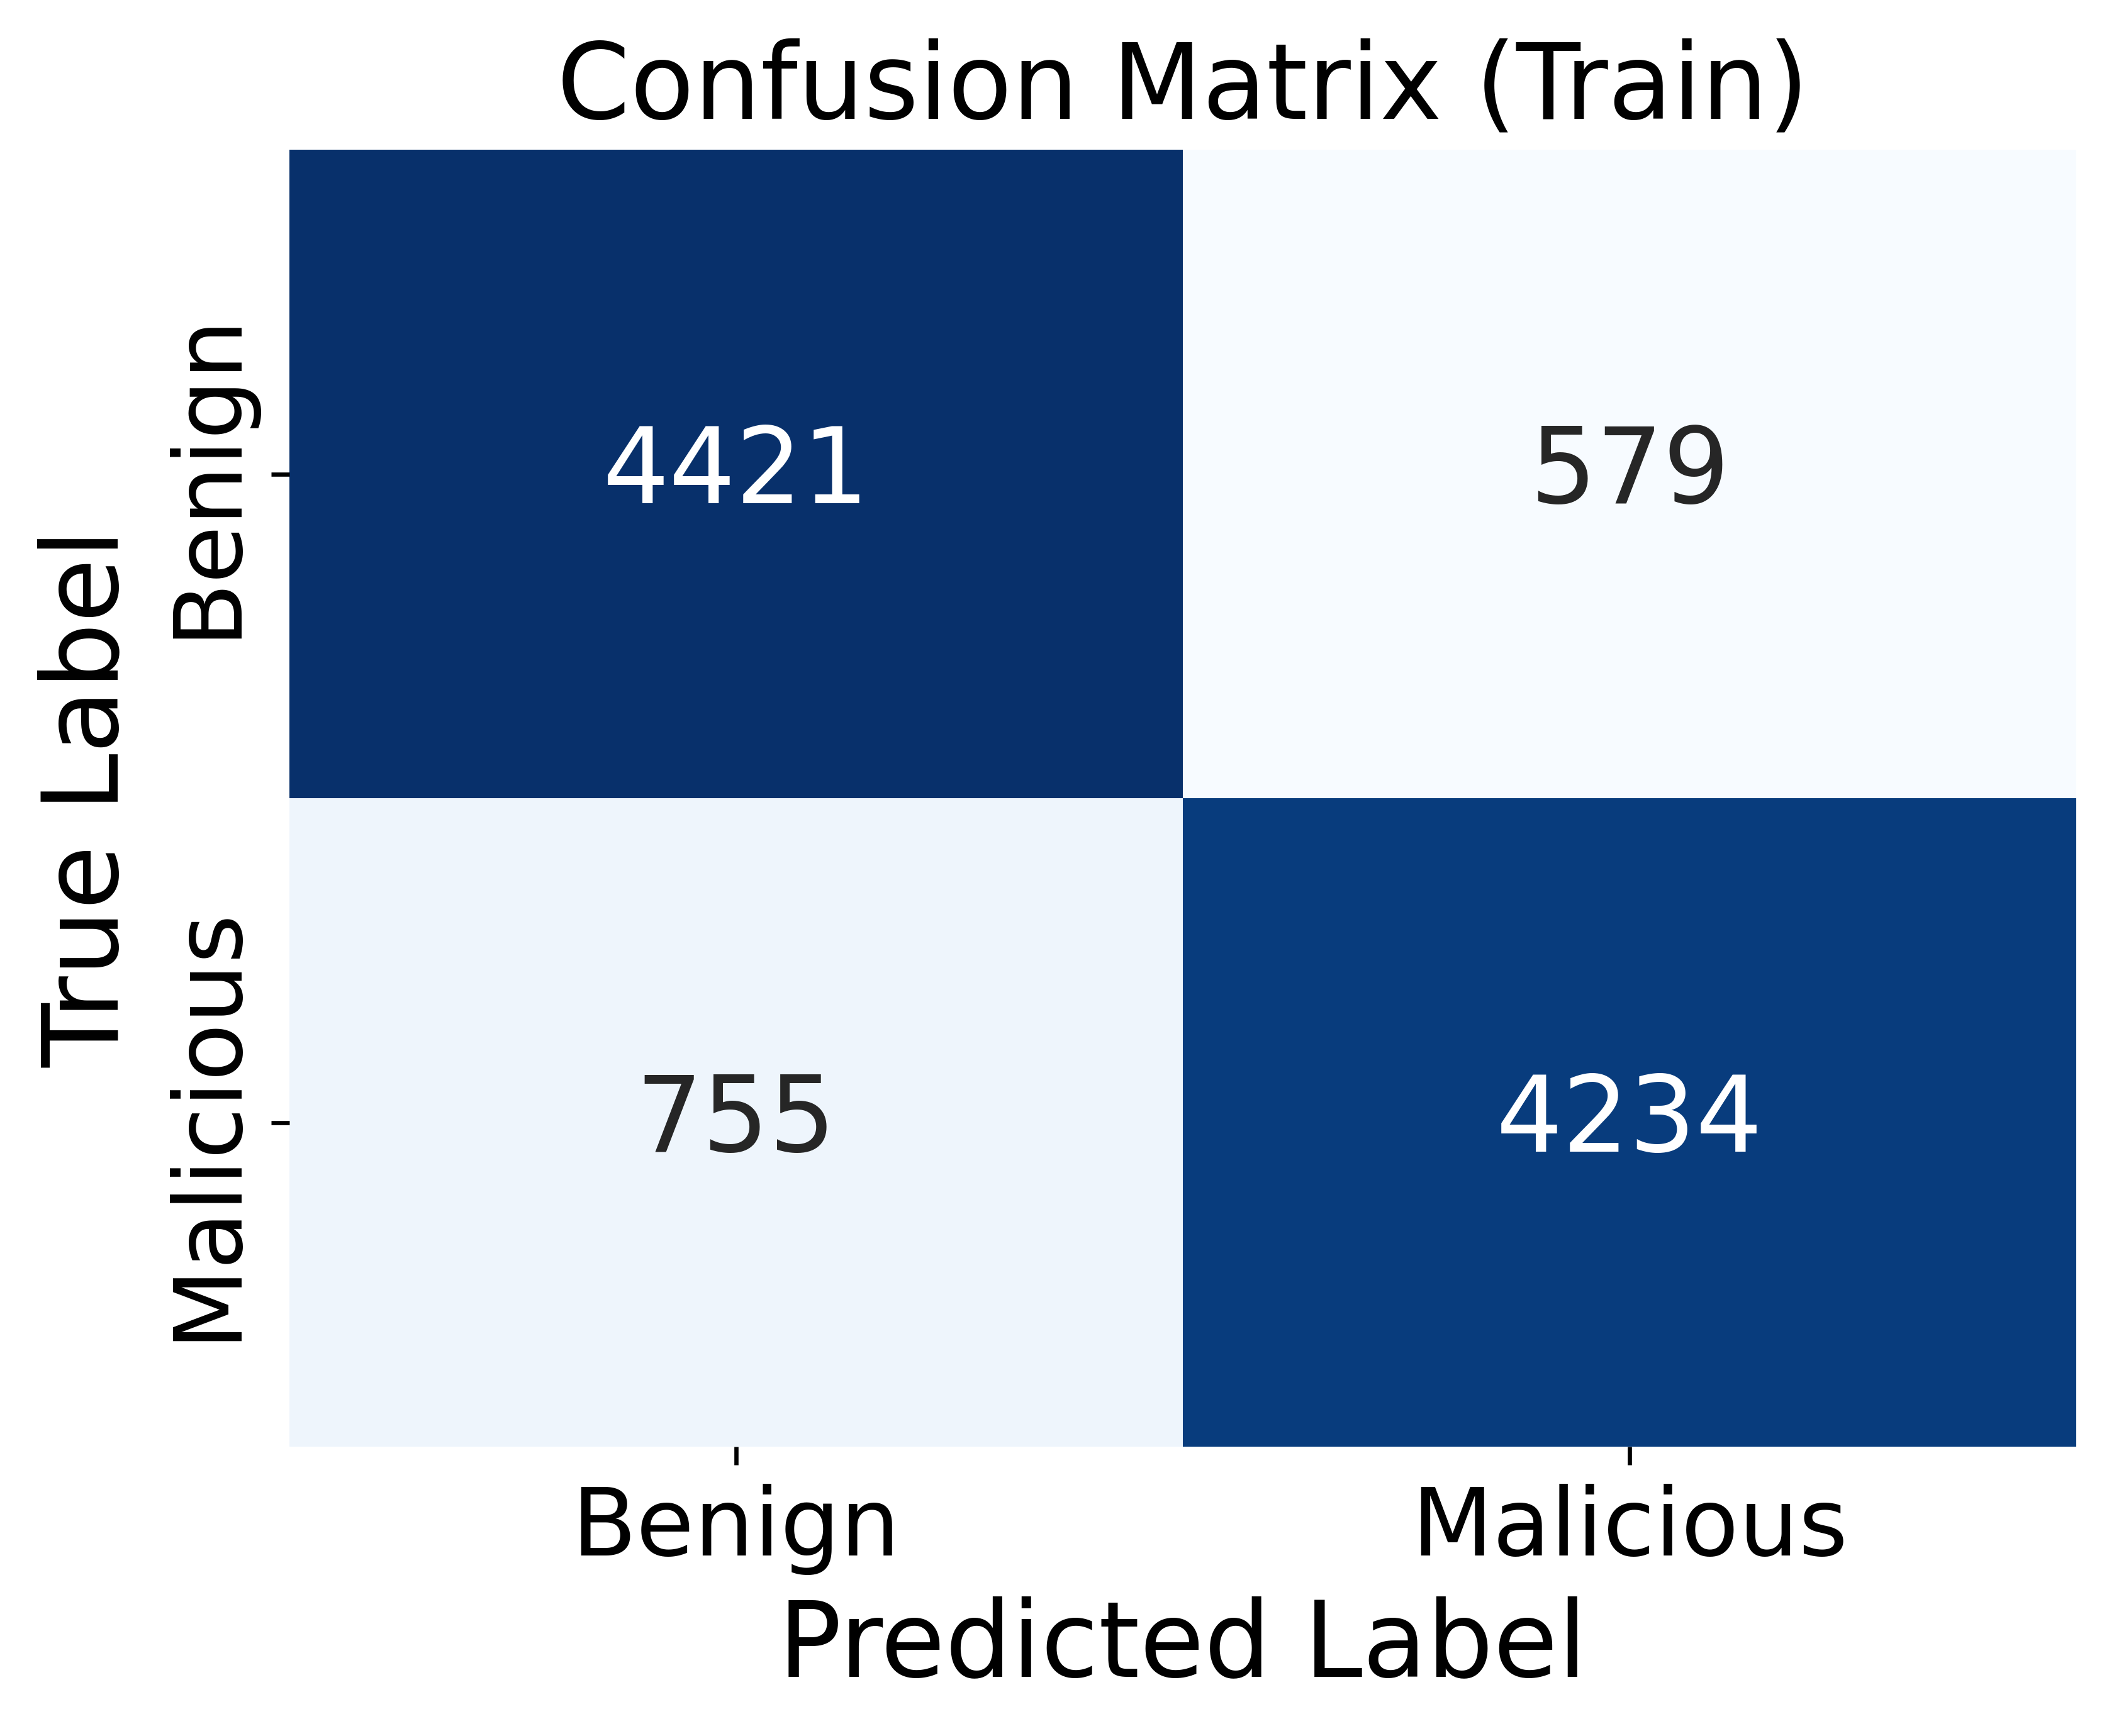

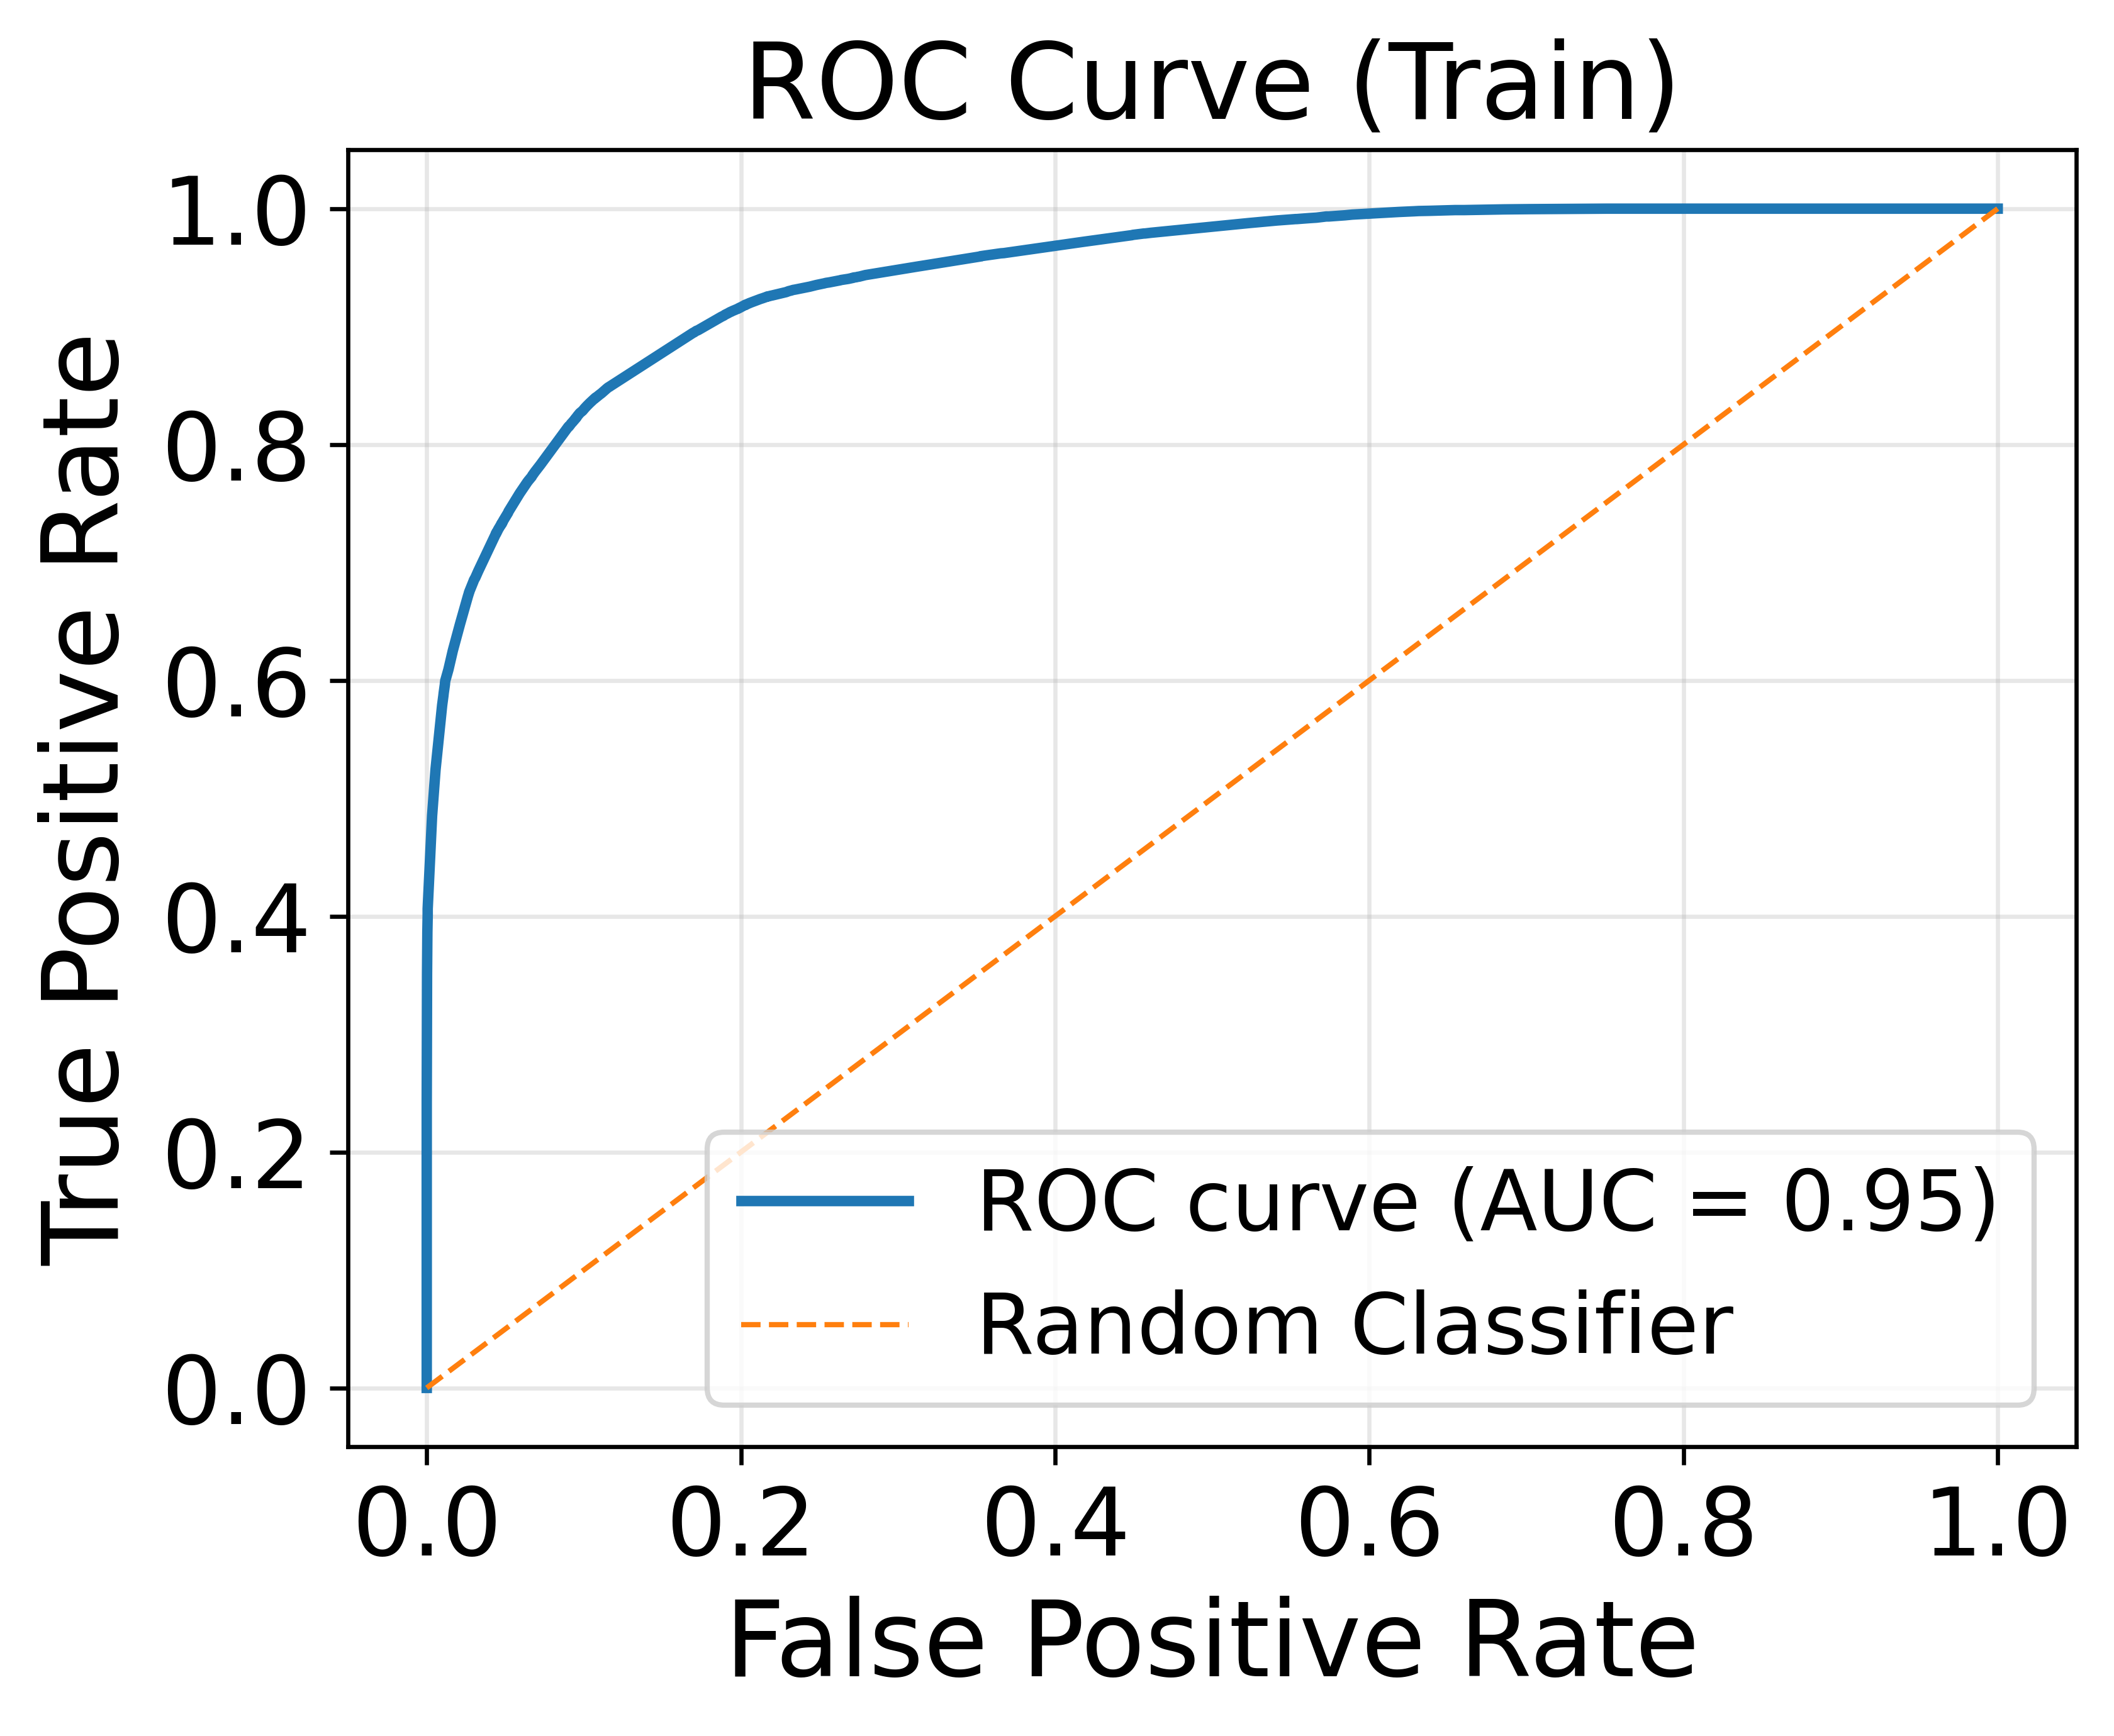


Evaluation Results: Validation
Accuracy  : 0.858944
Precision : 0.877089
Recall    : 0.834425
F1-score  : 0.855225
ROC AUC   : 0.924214
----------------------------------------------------------------------
Classification Report:
              precision    recall  f1-score   support

         0.0   0.842527  0.883396  0.862477      1072
         1.0   0.877089  0.834425  0.855225      1069

    accuracy                       0.858944      2141
   macro avg   0.859808  0.858910  0.858851      2141
weighted avg   0.859784  0.858944  0.858856      2141



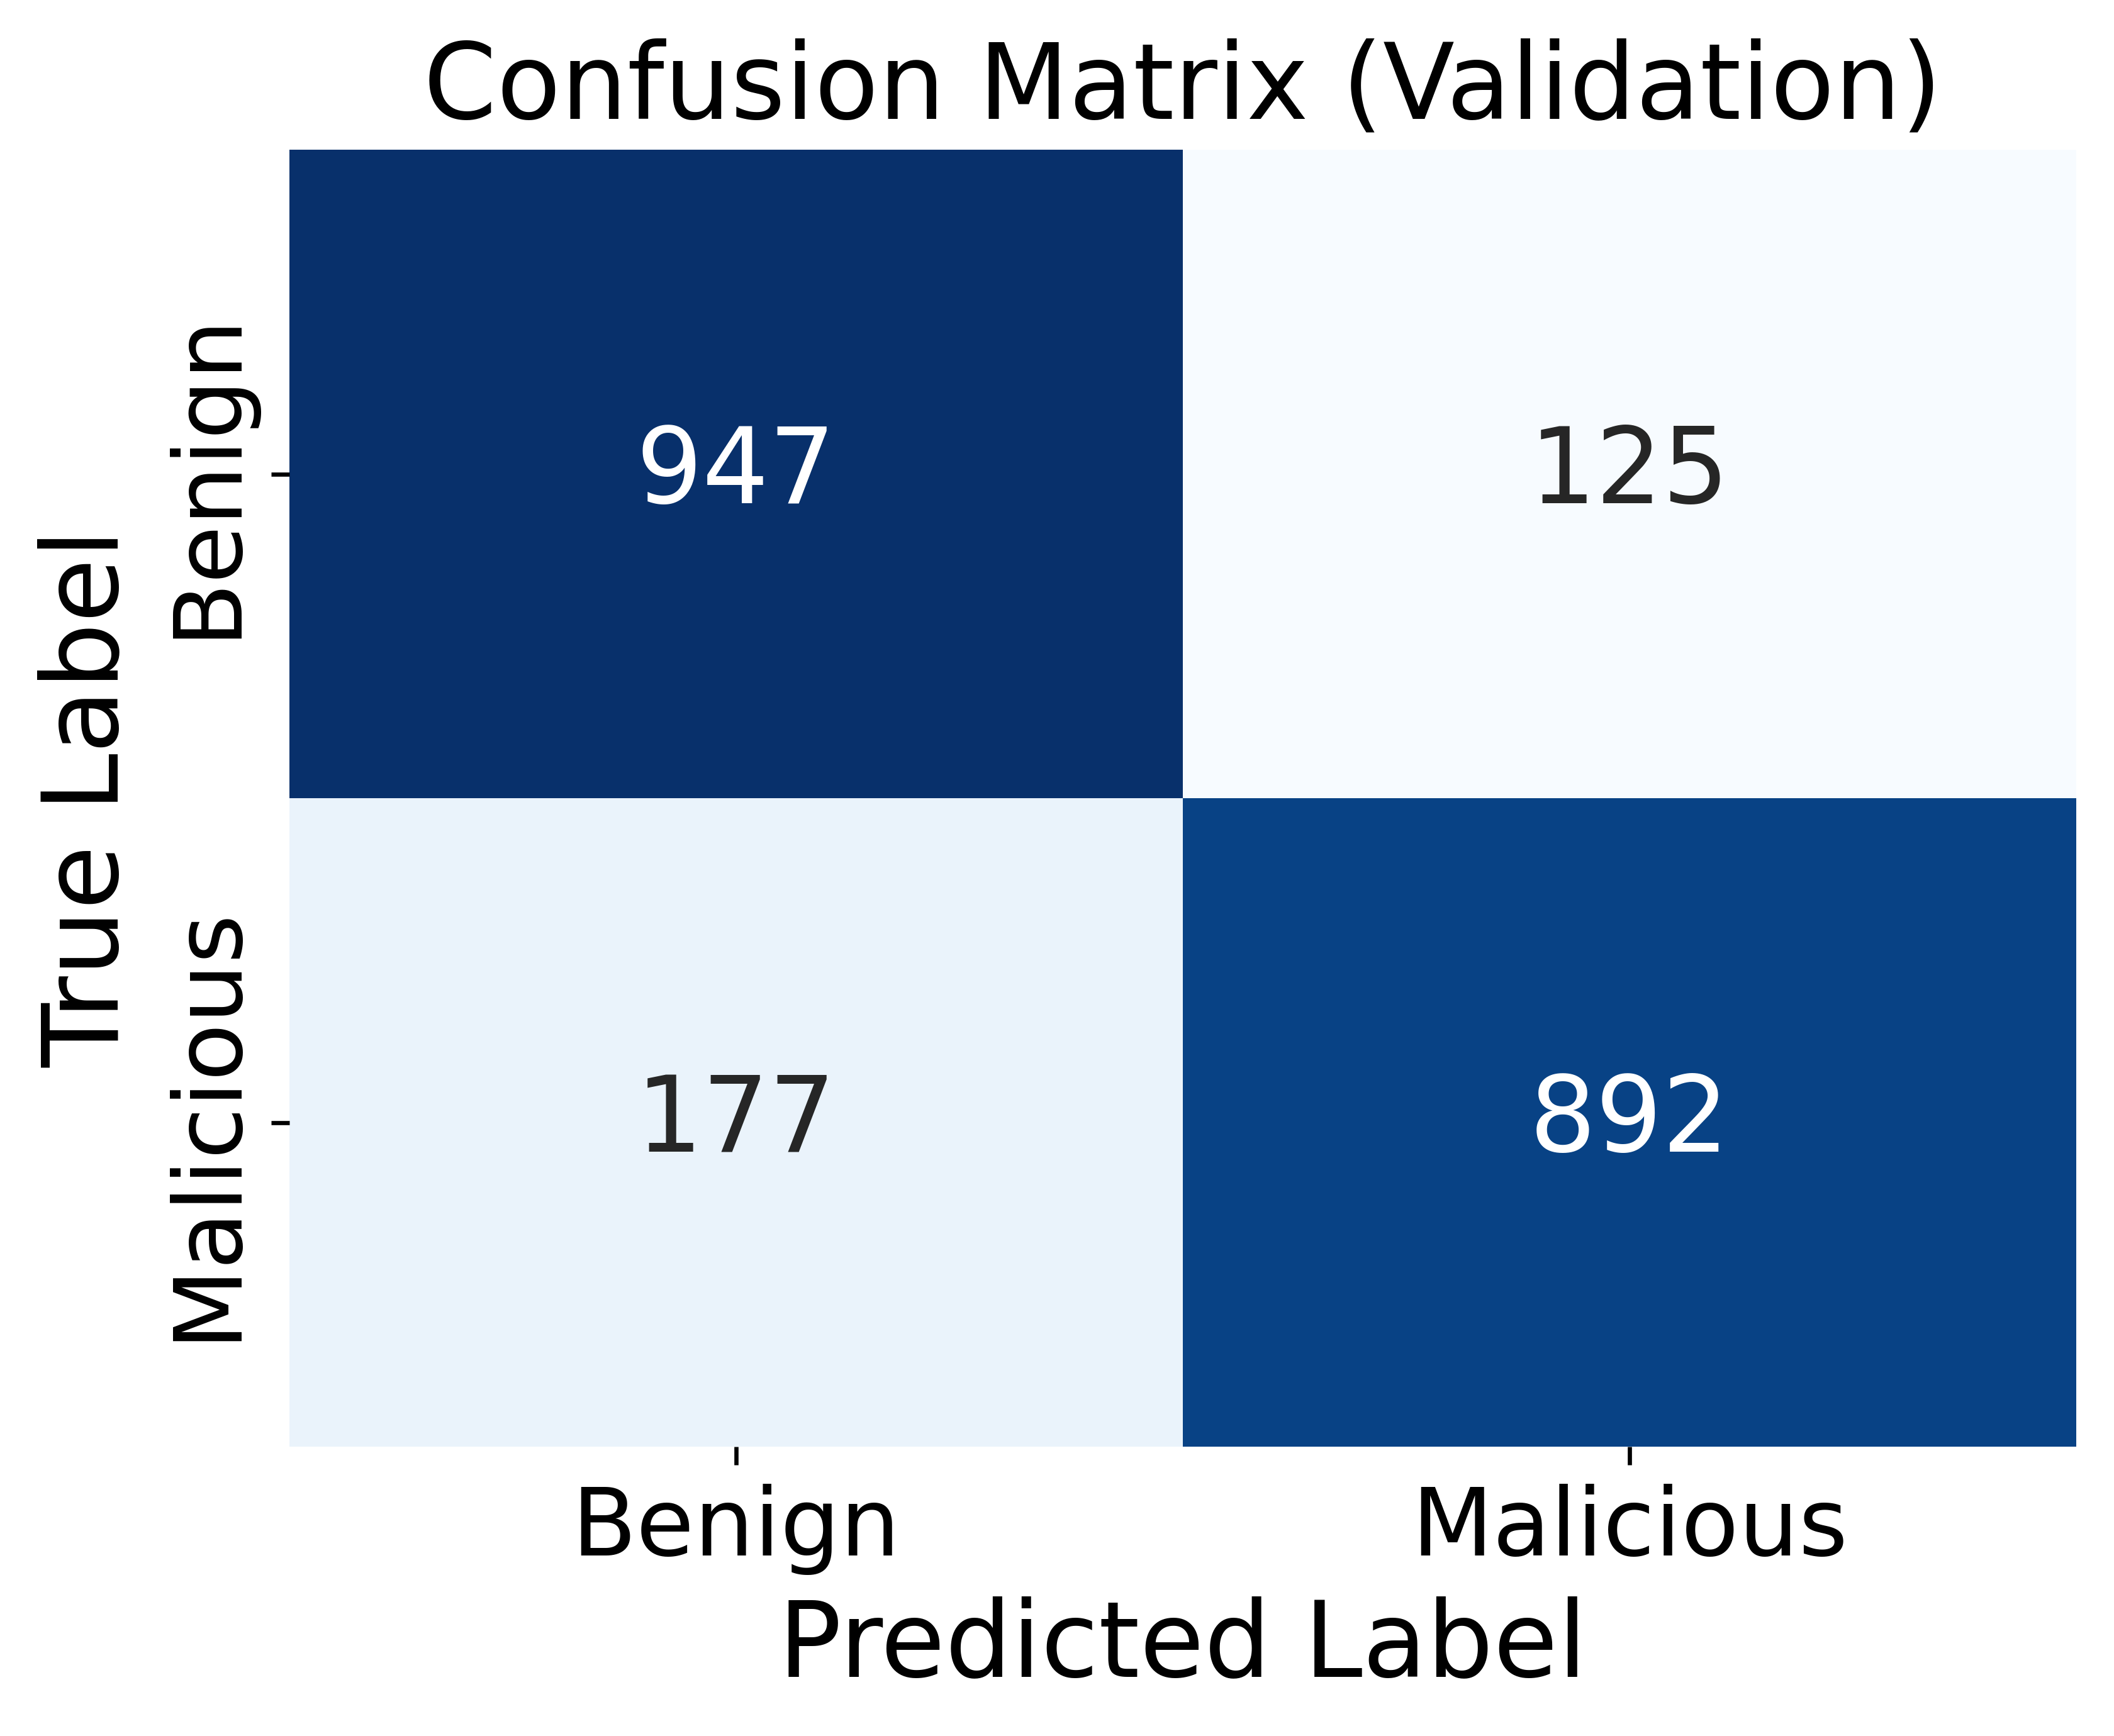

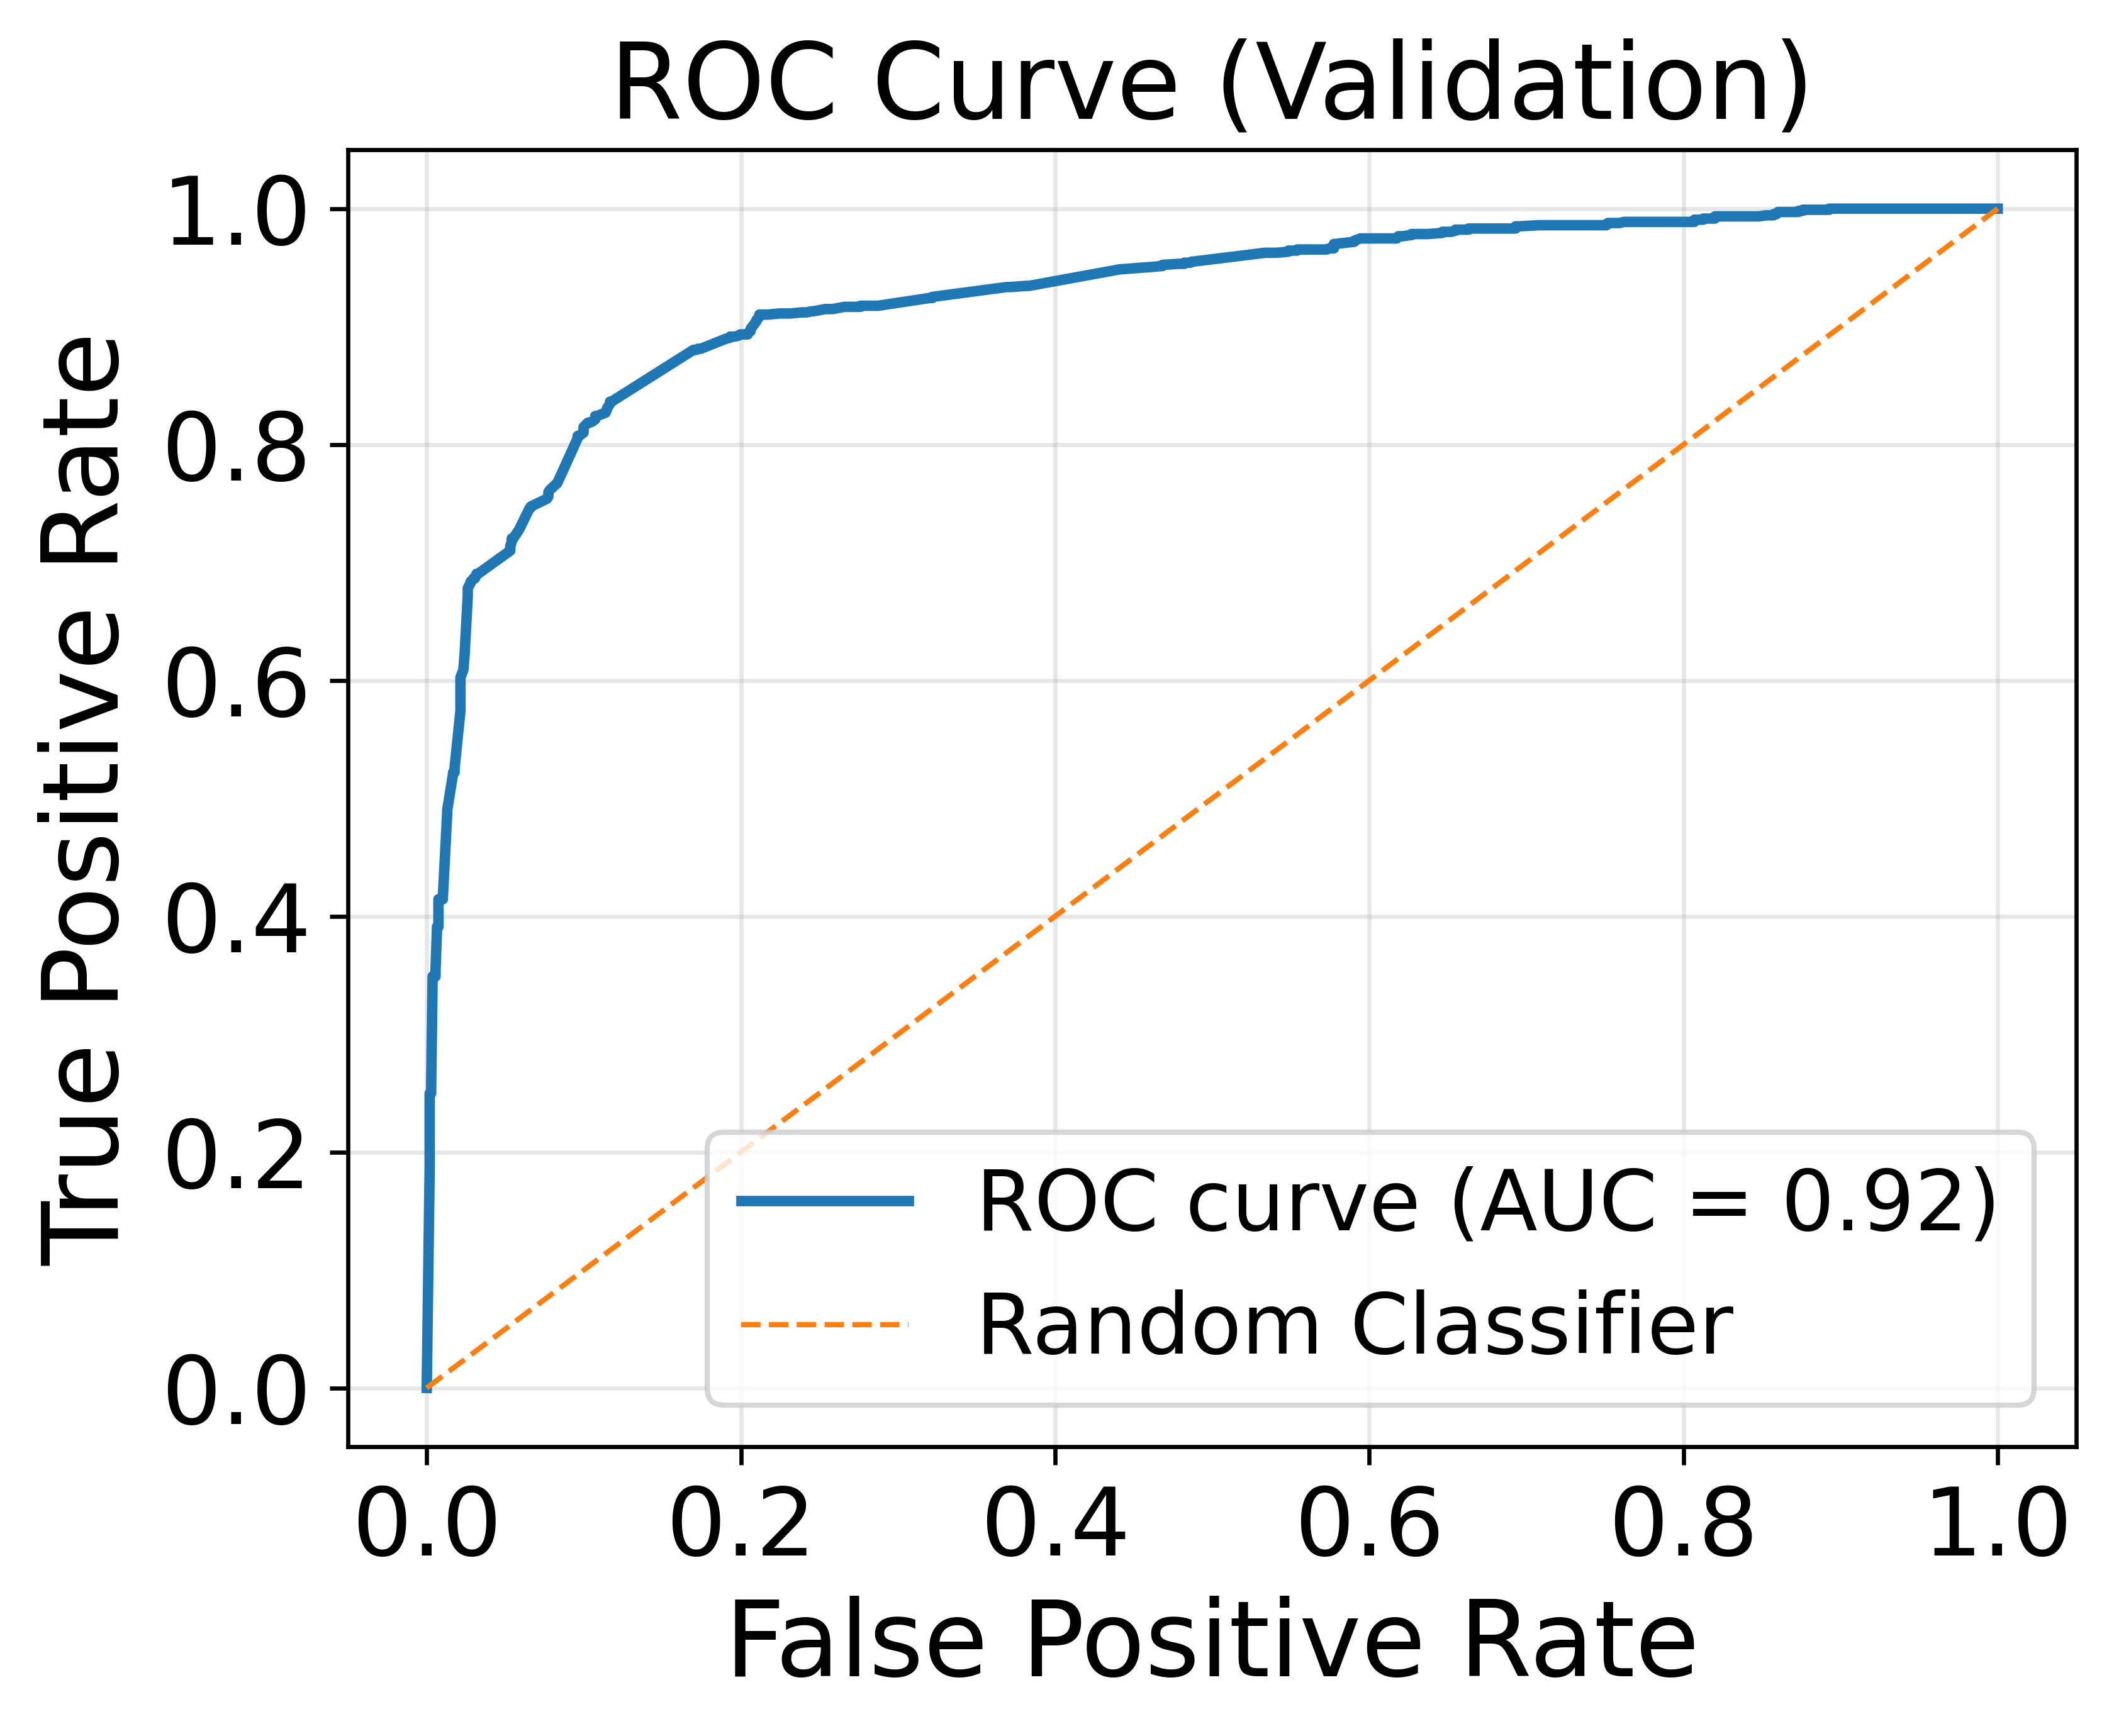


Evaluation Results: Test
Accuracy  : 0.851004
Precision : 0.855787
Recall    : 0.843779
F1-score  : 0.849741
ROC AUC   : 0.917926
----------------------------------------------------------------------
Classification Report:
              precision    recall  f1-score   support

         0.0   0.846366  0.858209  0.852246      1072
         1.0   0.855787  0.843779  0.849741      1069

    accuracy                       0.851004      2141
   macro avg   0.851077  0.850994  0.850994      2141
weighted avg   0.851070  0.851004  0.850995      2141



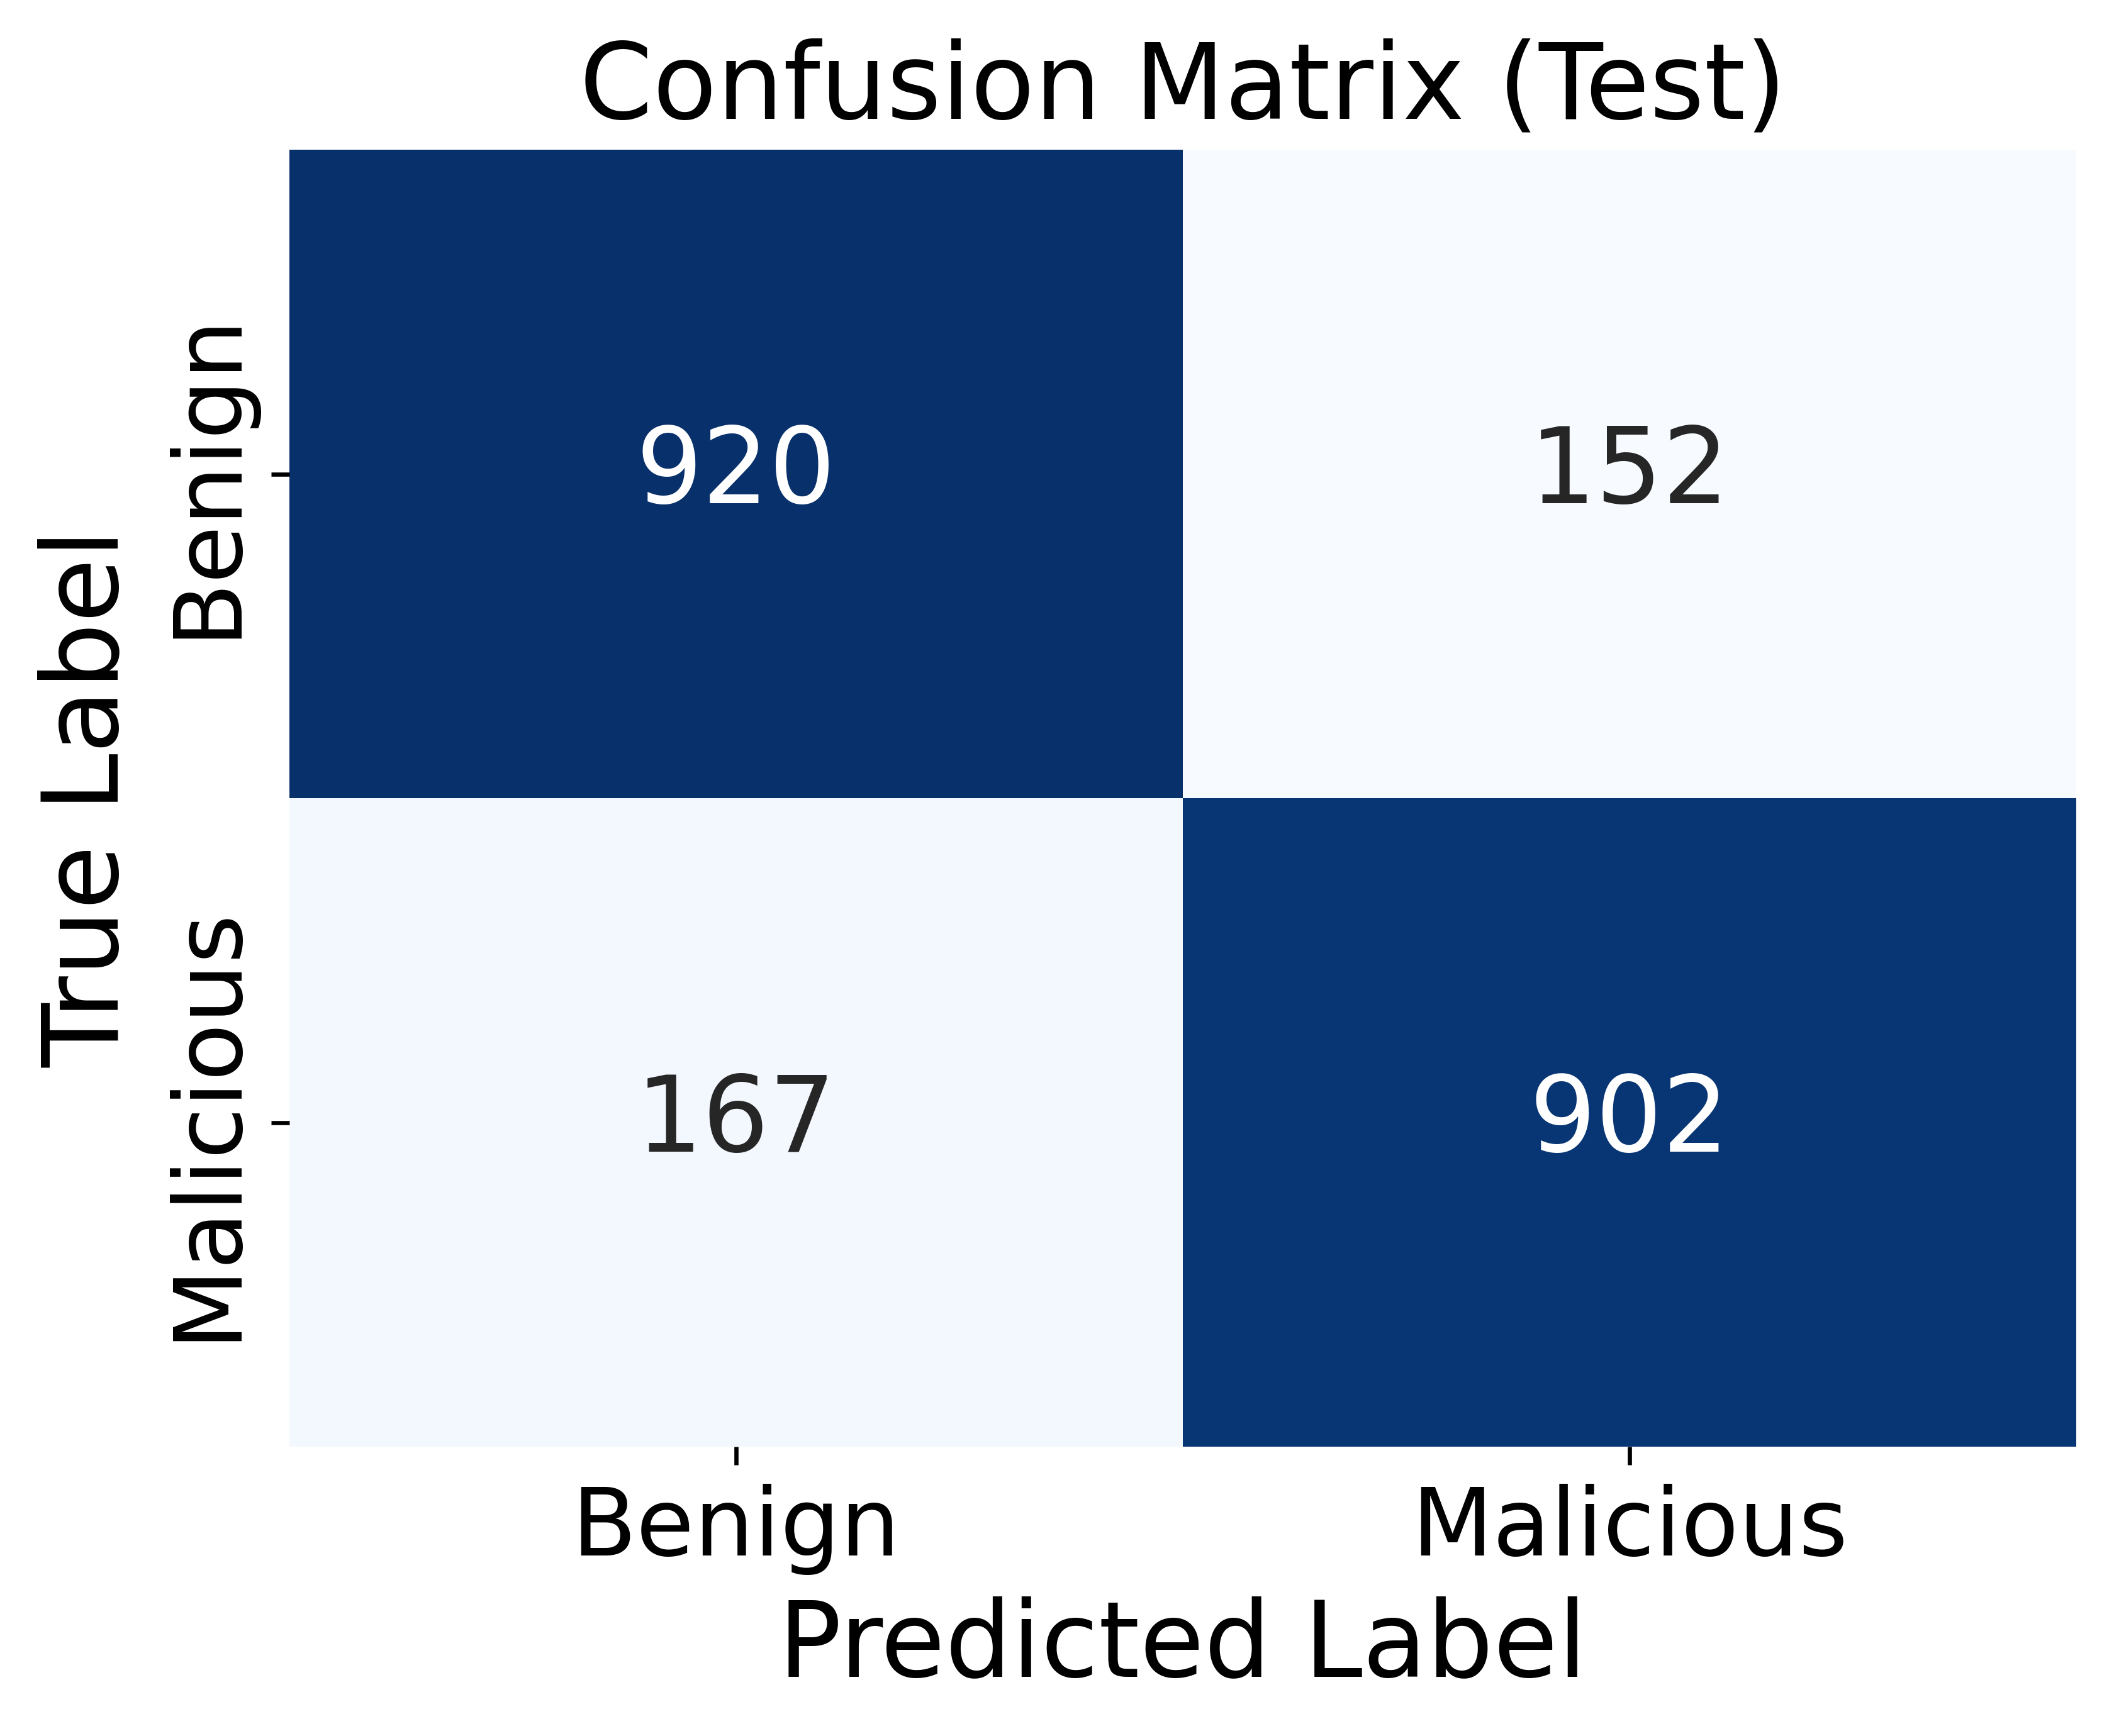

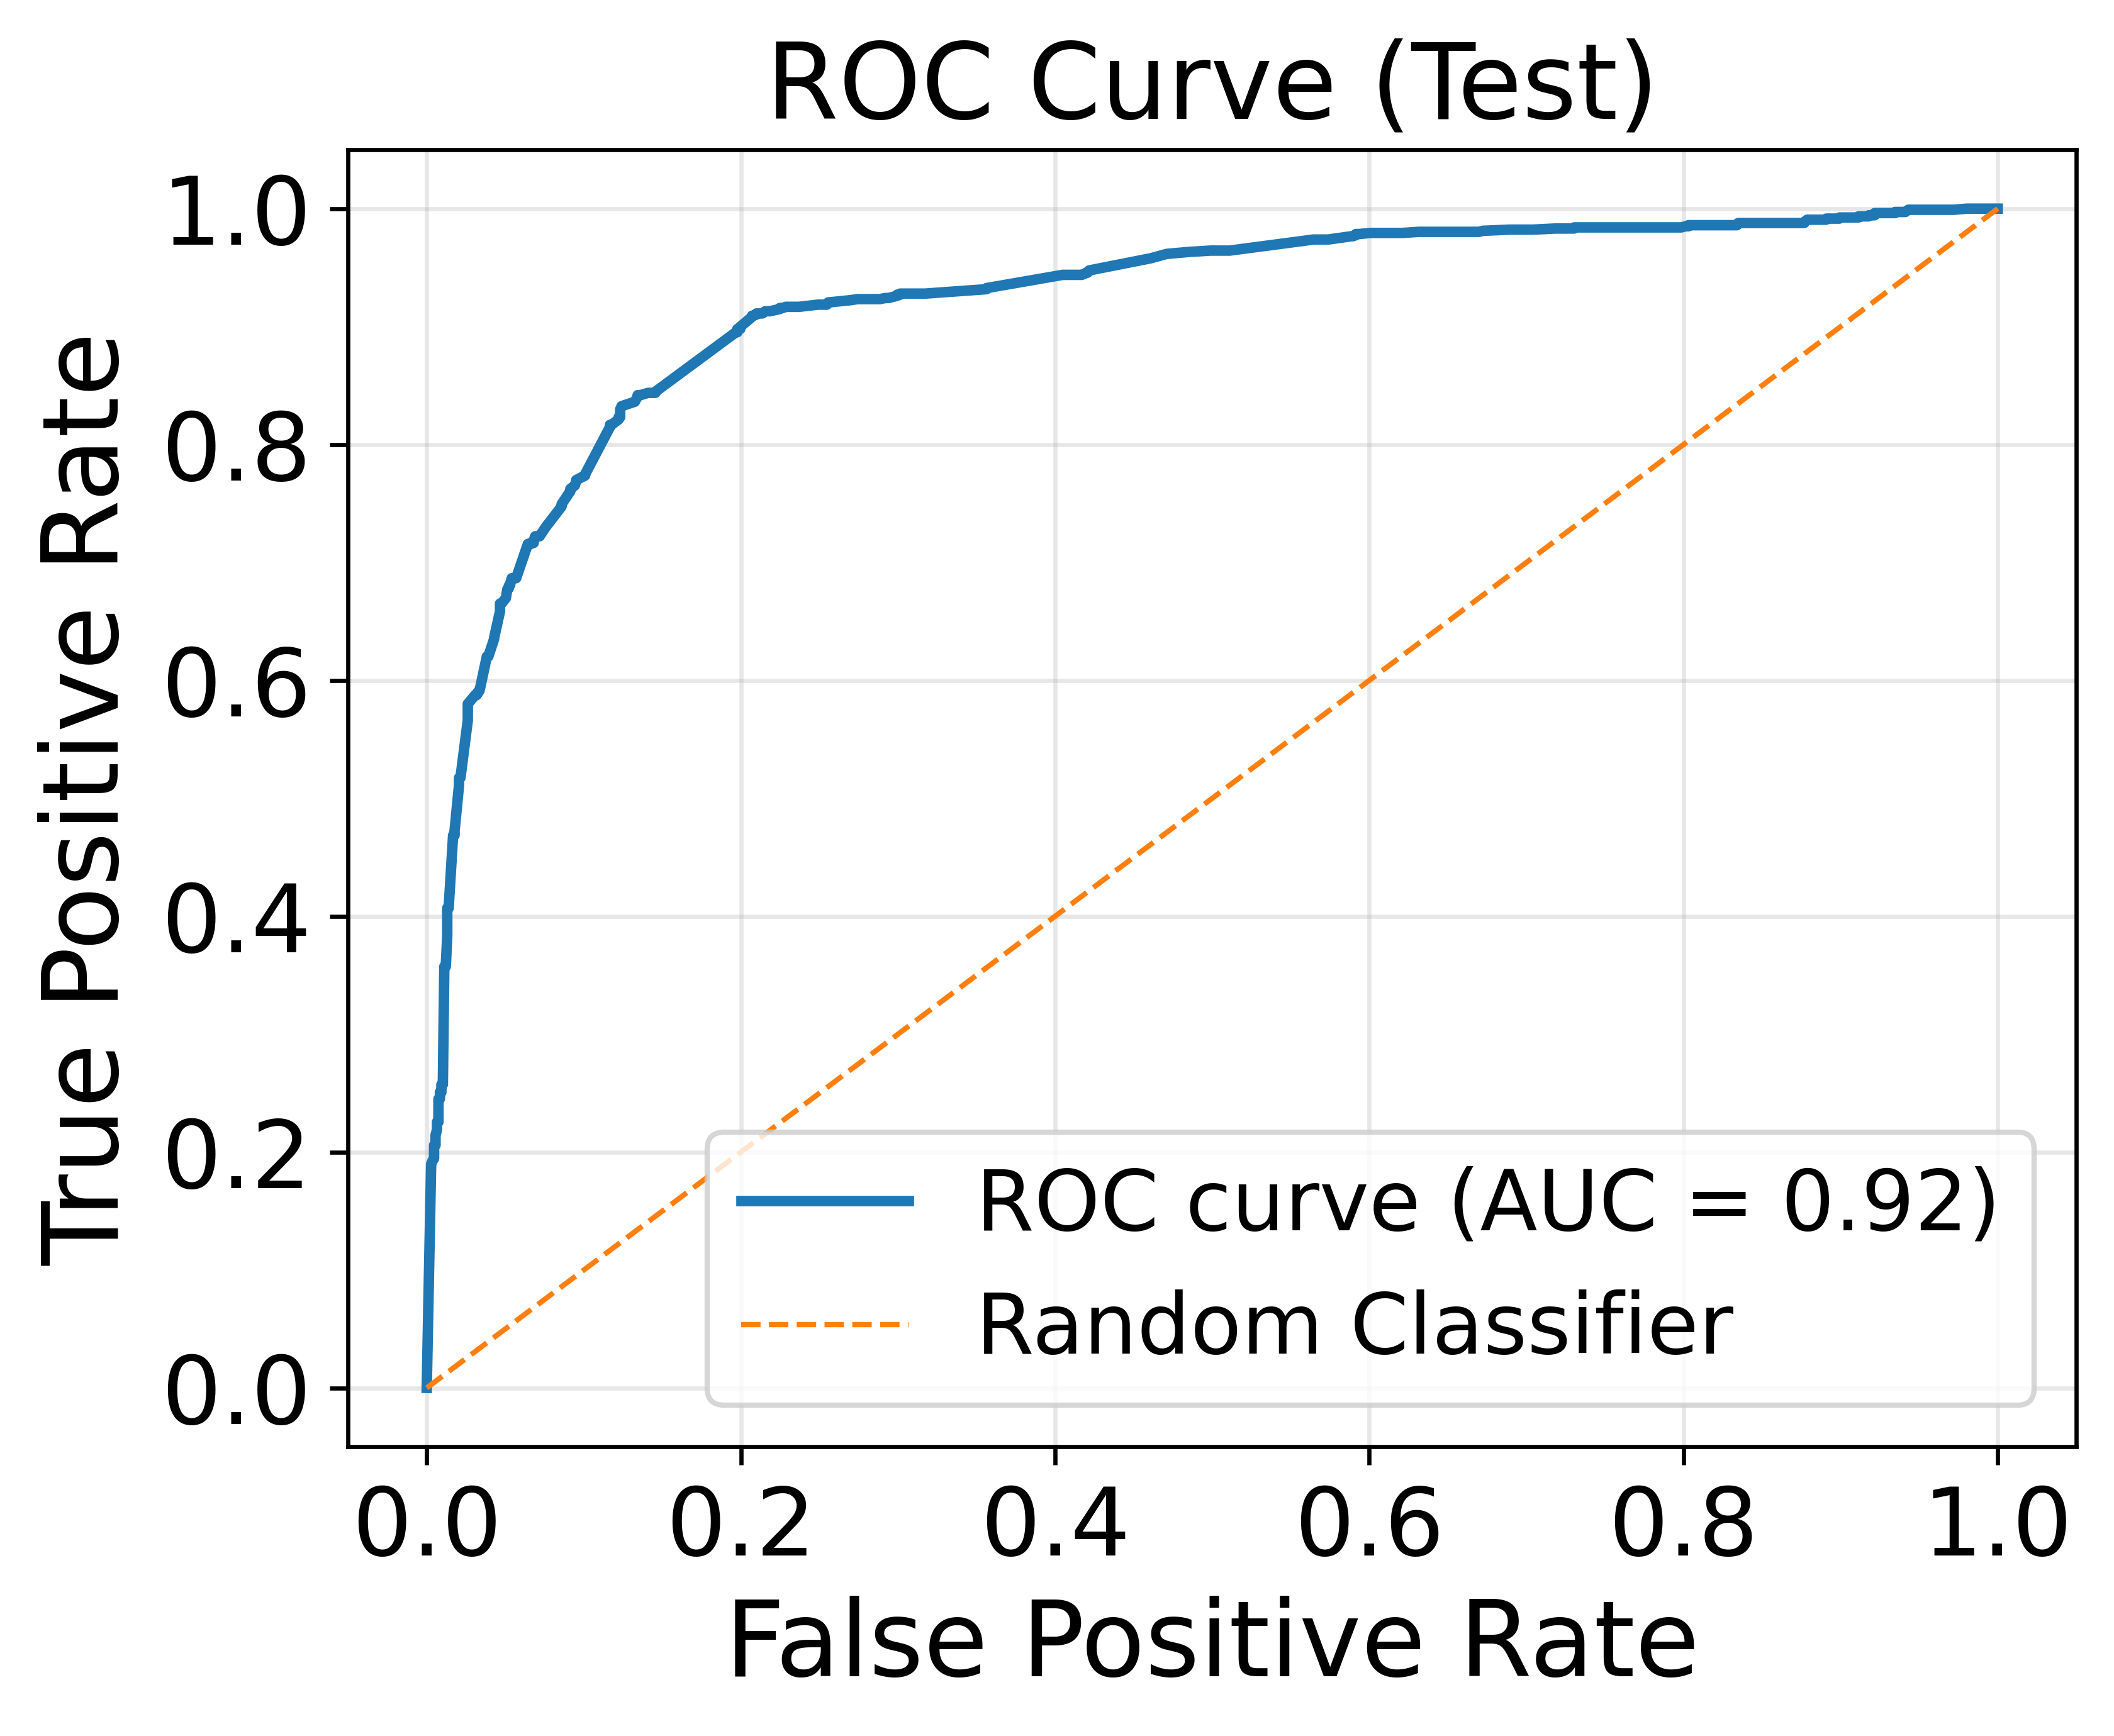

In [20]:
def evaluate_and_plot(model, encodings, X_num, y_true, dataset_name, output_dir=OUTPUT_DIR):
    """
    Evaluate the trained model on a given dataset and generate
    publication-quality confusion matrix and ROC curve figures.

    Parameters
    ----------
    model : keras.Model
        Trained classification model.
    encodings : dict or BatchEncoding
        Tokenized transformer inputs containing 'input_ids' and 'attention_mask'.
    X_num : np.ndarray or sparse matrix
        Additional numerical feature matrix.
    y_true : array-like
        Ground-truth labels.
    dataset_name : str
        Name of the dataset split (e.g., 'Train', 'Validation', 'Test').
    output_dir : str, optional
        Directory where evaluation figures will be saved.

    Returns
    -------
    results : dict
        Dictionary containing predictions and evaluation metrics.
    """

    # --------------------------------------------------------
    # Prepare model inputs
    # --------------------------------------------------------
    inputs = [
        np.array(encodings["input_ids"]),
        np.array(encodings["attention_mask"]),
        X_num
    ]

    # --------------------------------------------------------
    # Generate predictions
    # --------------------------------------------------------
    y_prob = model.predict(inputs, verbose=0).ravel()
    y_pred = (y_prob > 0.5).astype("int32")

    # --------------------------------------------------------
    # Compute evaluation metrics
    # --------------------------------------------------------
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)

    cm = confusion_matrix(y_true, y_pred)
    report = classification_report(y_true, y_pred, digits=6)

    # --------------------------------------------------------
    # Print evaluation summary
    # --------------------------------------------------------
    print("\n" + "=" * 70)
    print(f"Evaluation Results: {dataset_name}")
    print("=" * 70)
    print(f"Accuracy  : {acc:.6f}")
    print(f"Precision : {prec:.6f}")
    print(f"Recall    : {rec:.6f}")
    print(f"F1-score  : {f1:.6f}")
    print(f"ROC AUC   : {roc_auc:.6f}")
    print("-" * 70)
    print("Classification Report:")
    print(report)

    # --------------------------------------------------------
    # Plot and save confusion matrix
    # --------------------------------------------------------
    plt.figure(figsize=(6, 5), dpi=600)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=["Benign", "Malicious"],
        yticklabels=["Benign", "Malicious"]
    )
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix ({dataset_name})")
    plt.tight_layout()

    cm_png = os.path.join(output_dir, f"confusion_matrix_{dataset_name.lower()}.png")
    cm_pdf = os.path.join(output_dir, f"confusion_matrix_{dataset_name.lower()}.pdf")
    plt.savefig(cm_png, dpi=600, bbox_inches="tight")
    plt.savefig(cm_pdf, bbox_inches="tight")
    plt.show()

    # --------------------------------------------------------
    # Plot and save ROC curve
    # --------------------------------------------------------
    plt.figure(figsize=(6, 5), dpi=600)
    plt.plot(fpr, tpr, linewidth=2, label=f"ROC curve (AUC = {roc_auc:.2f})")
    plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1, label="Random Classifier")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve ({dataset_name})")
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.tight_layout()

    roc_png = os.path.join(output_dir, f"roc_curve_{dataset_name.lower()}.png")
    roc_pdf = os.path.join(output_dir, f"roc_curve_{dataset_name.lower()}.pdf")
    plt.savefig(roc_png, dpi=600, bbox_inches="tight")
    plt.savefig(roc_pdf, bbox_inches="tight")
    plt.show()

    # --------------------------------------------------------
    # Return results for further analysis/reporting
    # --------------------------------------------------------
    results = {
        "dataset": dataset_name,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1_score": f1,
        "roc_auc": roc_auc,
        "confusion_matrix": cm,
        "classification_report": report,
        "y_true": np.array(y_true),
        "y_pred": y_pred,
        "y_prob": y_prob,
        "confusion_matrix_png": cm_png,
        "confusion_matrix_pdf": cm_pdf,
        "roc_curve_png": roc_png,
        "roc_curve_pdf": roc_pdf
    }

    return results


# ============================================================
# Evaluate on Training, Validation, and Test Sets
# ============================================================

train_results = evaluate_and_plot(model, train_enc, X_train_num, y_train, "Train")
val_results   = evaluate_and_plot(model, val_enc, X_val_num, y_val, "Validation")
test_results  = evaluate_and_plot(model, test_enc, X_test_num, y_test, "Test")

### Save All Results

In [21]:
# ------------------------------------------------------------
# Create summary DataFrame
# ------------------------------------------------------------
summary_df = pd.DataFrame([
    {
        "Dataset": train_results["dataset"],
        "Accuracy": train_results["accuracy"],
        "Precision": train_results["precision"],
        "Recall": train_results["recall"],
        "F1-score": train_results["f1_score"],
        "ROC AUC": train_results["roc_auc"]
    },
    {
        "Dataset": val_results["dataset"],
        "Accuracy": val_results["accuracy"],
        "Precision": val_results["precision"],
        "Recall": val_results["recall"],
        "F1-score": val_results["f1_score"],
        "ROC AUC": val_results["roc_auc"]
    },
    {
        "Dataset": test_results["dataset"],
        "Accuracy": test_results["accuracy"],
        "Precision": test_results["precision"],
        "Recall": test_results["recall"],
        "F1-score": test_results["f1_score"],
        "ROC AUC": test_results["roc_auc"]
    }
])

# ------------------------------------------------------------
# Define save paths
# ------------------------------------------------------------
csv_path  = os.path.join(OUTPUT_DIR, "evaluation_summary.csv")
xlsx_path = os.path.join(OUTPUT_DIR, "evaluation_summary.xlsx")

# ------------------------------------------------------------
# Save files
# ------------------------------------------------------------
summary_df.to_csv(csv_path, index=False)
summary_df.to_excel(xlsx_path, index=False)

# ------------------------------------------------------------
# Confirmation
# ------------------------------------------------------------
print("=" * 60)
print("Evaluation summary saved successfully:")
print(f"CSV  : {csv_path}")
print(f"Excel: {xlsx_path}")
print("=" * 60)

# Display table
summary_df

Evaluation summary saved successfully:
CSV  : Evaluation_Outputs_Pattern_FLAML_Attention_DistilGPT2/evaluation_summary.csv
Excel: Evaluation_Outputs_Pattern_FLAML_Attention_DistilGPT2/evaluation_summary.xlsx


,Dataset,Accuracy,Precision,Recall,F1-score,ROC AUC
0,Train,0.866453,0.879701,0.848667,0.863905,0.945090
1,Validation,0.858944,0.877089,0.834425,0.855225,0.924214
2,Test,0.851004,0.855787,0.843779,0.849741,0.917926


### Clear Final Backend Session

In [22]:
# ============================================================
# Memory Management and Session Reset
# ============================================================

# Trigger garbage collection to free unused memory
gc.collect()

# Clear the current TensorFlow/Keras session to release GPU/CPU resources
# This is particularly important when training multiple models sequentially
tf.keras.backend.clear_session()